# Function 2 - Bayesian Optimization

## Function 2 Description

Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.

To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

Log-likelihood scores are negative numbers (e.g., -754.13) that represent the logarithm of the probability that a specific model fits a dataset, ranging from -∞ to 0. Because they are logarithmic, they are always negative, and closer to 0 is better (indicates a better fit).

## Starting point
*  Input - 2D array (10,2)
*  Output - 1D array (10,)
*  Optimisation goal - Maximise

## Bayesian Optimization (BO) workflow on capstone project

*   BO with Upper Control Bound (UCB)
*   Visuals of progress and surrogate intuition
*   Final training with the optimized hyperparameters



### Import Libraries

In [1]:
import io, math, pathlib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

#### Setup Parameters

In [2]:
plt.rcParams['figure.figsize'] = (5,3)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True

### Assign Data to variables X and y

In [3]:
import numpy as np, pandas as pd, pathlib

# To load a .npy file into a pandas DataFrame:
# 1. Load the .npy file using numpy.load()
# 2. Convert the resulting numpy array to a pandas DataFrame using pd.DataFrame()

# Attempting to load from '/content/data/' as is common in Colab, or from a 'data/' subfolder
try:
    # Try loading from /content/data/
    X_array = np.load('/content/data/initial_inputs2.npy')
    y_array = np.load('/content/data/initial_outputs2.npy')
    print("Files loaded successfully from /content/data/")

except FileNotFoundError:
    try:
        # If not in /content/data/, try loading from a 'data/' subfolder in the current directory
        X_array = np.load('data/initial_inputs2.npy')
        y_array = np.load('data/initial_outputs2.npy')
        print("Files loaded successfully from data/ subfolder.")
    except FileNotFoundError:
       print("Error: One or both .npy files not found at /content/data/ or data/.")
       print("Please ensure they are in the correct path.")
       print("Current working directory files: ", list(pathlib.Path().absolute().glob('*.npy')))
       print("Files in /content/data/: ", list(pathlib.Path('/content/data/').absolute().glob('*.npy')))

       # Create dummy data if files are not found to allow notebook execution to proceed
       X_array = np.random.rand(10, 2) # Example: 10 samples, 8 features
       y_array = np.random.rand(10,)  # Example: 10 samples, 1 output
       print("\nUsing dummy data for X and y to continue.")

# Convert to DataFrame if needed, or use as NumPy arrays directly for your model
X_df = pd.DataFrame(X_array)
y_df = pd.DataFrame(y_array, columns=['target_output'])

print("Shape of X (NumPy array):", X_array.shape)
print("Shape of y (NumPy array):", y_array.shape)
print("\nFirst 5 rows of X (DataFrame):")
display(X_df.head())
print("\nFirst 5 rows of y (DataFrame):")
display(y_df.head())

# Assign X and y for subsequent steps (as NumPy arrays, based on original notebook context)
X = X_array
y = y_array


Files loaded successfully from /content/data/
Shape of X (NumPy array): (10, 2)
Shape of y (NumPy array): (10,)

First 5 rows of X (DataFrame):


,0,1
0,0.665800,0.123969
1,0.877791,0.778628
2,0.142699,0.349005
3,0.845275,0.711120
4,0.454647,0.290455



First 5 rows of y (DataFrame):


,target_output
0,0.538996
1,0.420586
2,-0.065624
3,0.293993
4,0.214965


To add new data points, you'll need to create new NumPy arrays for the input features (`new_X_points`) and target outputs (`new_y_points`). Ensure that the new points have the same number of features as your existing `X` array.

Then, use `np.vstack` to vertically stack the new `X` points onto the existing `X` array, and `np.concatenate` to combine the new `y` points with the existing `y` array.

In [4]:
import numpy as np

# Assume X and y are already defined from previous cells
# Example: X_array.shape = (10, 2), y_array.shape = (10,)

# Create new data points
# Make sure new_X_points has the same number of columns as X
# and new_y_points has compatible dimensions with y

# For X (features), assume 2 features per data point
# Let's add 3 new data points
new_X_points = np.array([
    [0.100000, 0.900000], # week 1 capstone submission - scatter pl0t
    [0.227370, 0.559809], # week 2 capstone submission - UCB KAPPA=30.0 for Exploration
    [0.849509, 0.014190], # week 3 capstone submission - UCB KAPPA=50.0 for Exploration
    [0.998348, 0.859169], # week 4 capstone submission - UCB KAPPA=200.0 for further exploration
    [0.424903, 0.924532], # week 5 capstone submission - UCB KAPPA=40.0 for Exploitation
    [0.935483, 0.147621], # week 6 capstone submission - UCB KAPPA=500 for Exploration
    [0.849509, 0.014190], # week 7 capstone submission - changed to objective function to Neg R2, UCB KAPPA = 40.0 for exploration
    [0.864591, 0.059341], # Week 8 capstone submission - UCB KAPPA = 40.0, now it is tagged as exploitation
    [0.878878, 0.779025], # Week 9 capstone submission - UCB KAPPA = 1000.0,for agressive exploration
    [0.469574, 0.927660], # Week 10 KAPPA set to 5.0 for exploitation, from BO, changed N_INIT to 10 and N_ITER to 30 and learning rate reduced to 0.001
    [0.989791, 0.926242], # Week 11 KAPPA set to 1.0 for exploitation, from BO
    [0.444765, 0.596075]  # Week 12 KAPPA set to 0.25 for exploitation and added min_samples_leaf to search space
   #[0.526233, 0.724365]  # Week 13 KAPPA set to 0.10 for exploitation

])

# For y (target), assume a single output value per data point
new_y_points = np.array([
   0.07713545370099886,  # week 1 capstone processed output
   0.012227290339340946, # week 2 capstone processed output
   0.02535974855326912,  # week 3 capstone processed output
   0.04820594088727147,  # week 4 ccapstone processed output
   -0.03758662429834346, # week 5 capstone processed output
   -0.03758662429834346, # week 6 capstone processed output
   -0.04155045397739051, # week 7 capstone processed output
   0.21119490235988547,  # week 8 capstone processed outputn
   0.4176775259417149,   # week 9 capstone processed output
   0.06403716155399637,  # week 10 capstone processed output
   -0.12657979582975754, # week 11 capstone processed output
   0.20358970661533243   # week 12 capstone processed output
   # week 13 capstone processed output

])

# Verify shapes before adding
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"New X points shape: {new_X_points.shape}")
print(f"New y points shape: {new_y_points.shape}")

# Add the new data points
X = np.vstack([X, new_X_points])
y = np.concatenate([y, new_y_points])

print(f"\nUpdated X shape: {X.shape}")
print(f"Updated y shape: {y.shape}")

# Display the last few rows to see the added data
print("\nLast 5 rows of updated X:")
display(pd.DataFrame(X).tail())
print("\nLast 5 rows of updated y:")
display(pd.DataFrame(y, columns=['target_output']).tail())


Original X shape: (10, 2)
Original y shape: (10,)
New X points shape: (12, 2)
New y points shape: (12,)

Updated X shape: (22, 2)
Updated y shape: (22,)

Last 5 rows of updated X:


,0,1
17,0.864591,0.059341
18,0.878878,0.779025
19,0.469574,0.927660
20,0.989791,0.926242
21,0.444765,0.596075



Last 5 rows of updated y:


,target_output
17,0.211195
18,0.417678
19,0.064037
20,-0.126580
21,0.203590


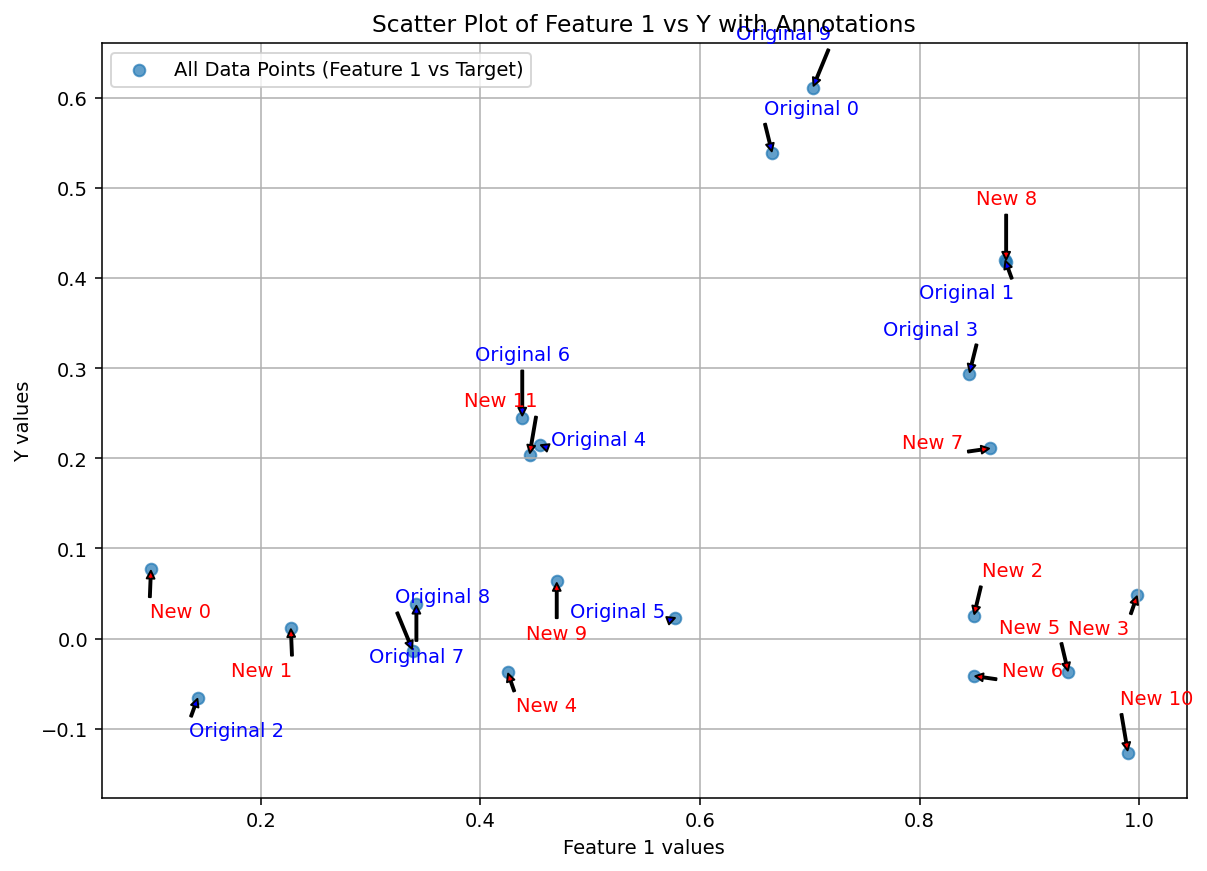

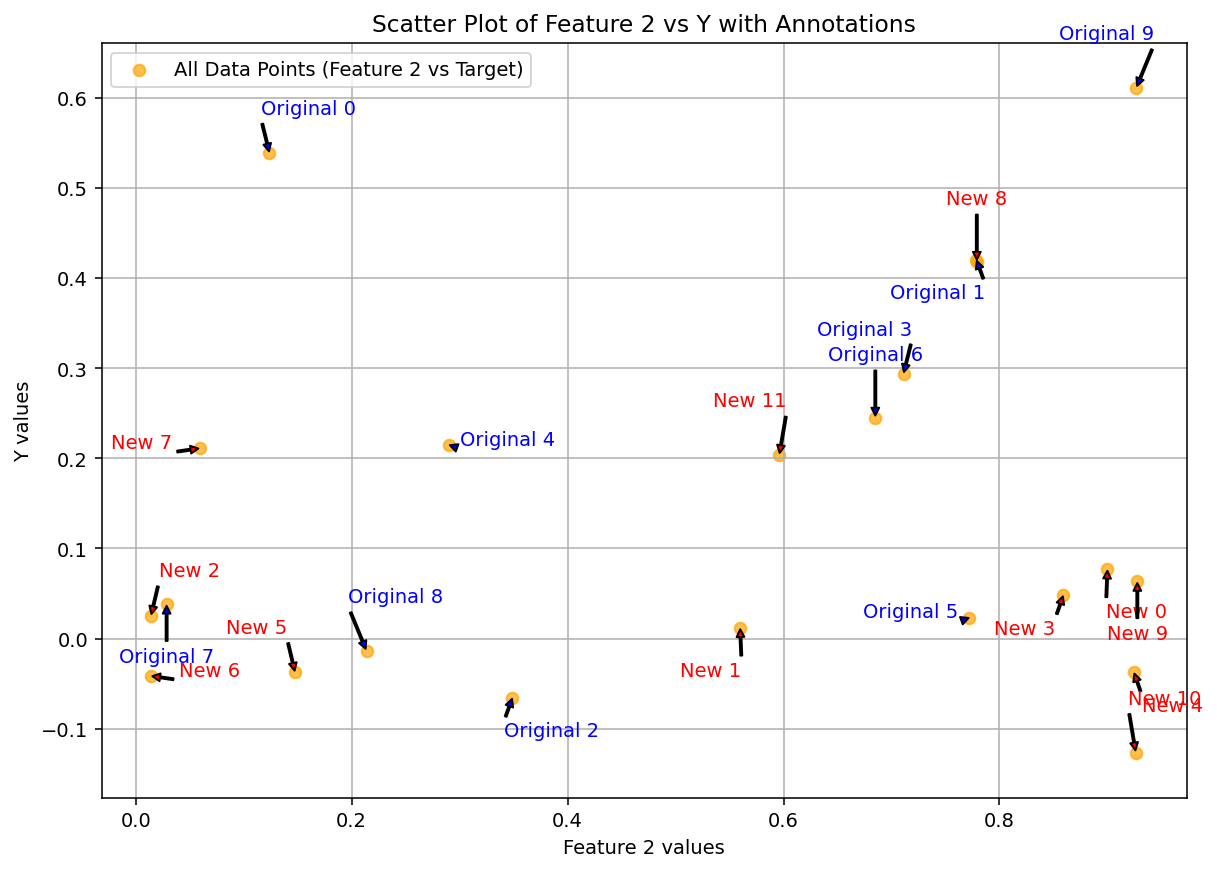

In [5]:
plt.figure(figsize=(10, 7)) # Increased figure size for better readability
plt.scatter(X[:, 0], y, label='All Data Points (Feature 1 vs Target)', alpha=0.7)
plt.xlabel('Feature 1 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 1 vs Y with Annotations')
plt.legend()
plt.grid(True)
plt.ylim(np.min(y) - 0.05, np.max(y) + 0.05) # Explicitly set y-axis limits

# Define a list of larger offsets to cycle through for better annotation placement
offsets = [
    (20, 20), (-20, -20), (20, -20), (-20, 20),
    (30, 0), (-30, 0), (0, 30), (0, -30),
    (15, 25), (-15, 25), (15, -25), (-15, -25)
]

# Annotate each point for Feature 1
num_original_points = X_array.shape[0]
for i in range(X.shape[0]):
    offset = offsets[i % len(offsets)] # Cycle through offsets
    if i < num_original_points:
        label = f'Original {i}'
        color = 'blue'
    else:
        label = f'New {i - num_original_points}'
        color = 'red' # Use a different color for new points to distinguish visually
    plt.annotate(
        label,
        (X[i, 0], y[i]),
        textcoords="offset points",
        xytext=offset,
        ha='center',
        color=color,
        arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=4, headlength=4)
    )
plt.show()

plt.figure(figsize=(10, 7)) # Increased figure size for better readability
plt.scatter(X[:, 1], y, label='All Data Points (Feature 2 vs Target)', color='orange', alpha=0.7)
plt.xlabel('Feature 2 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 2 vs Y with Annotations')
plt.legend()
plt.grid(True)
plt.ylim(np.min(y) - 0.05, np.max(y) + 0.05) # Explicitly set y-axis limits

# Annotate each point for Feature 2
for i in range(X.shape[0]):
    offset = offsets[i % len(offsets)] # Cycle through offsets
    if i < num_original_points:
        label = f'Original {i}'
        color = 'blue'
    else:
        label = f'New {i - num_original_points}'
        color = 'red' # Use a different color for new points to distinguish visually
    plt.annotate(
        label,
        (X[i, 1], y[i]),
        textcoords="offset points",
        xytext=offset,
        ha='center',
        color=color,
        arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=4, headlength=4)
    )
plt.show()

The 'y' values are negative log-likelihood scores, the points closest to zero (i.e., the least negative values) represent the best fit or highest log-likelihood. The goal is to maximise the log-likelihood, which translates to finding the 'y' values that are as close to zero as possible.

Finding the top 3 input (X) values that generated the BEST output (y) values (closest to zero):

Top 3 Best Output Values (y) and their corresponding X values:
   Original Index: 11
   y value: 1.2227290339e-02
   Corresponding X values: [0.22737  0.559809]


   Original Index: 8
   y value: -1.3857618150e-02
   Corresponding X values: [0.33864816 0.21386725]


   Original Index: 5
   y value: 2.3105549798e-02
   Corresponding X values: [0.57771284 0.77197318]


Finding the top 3 input (X) values that generated the WORST output (y) values (farthest from zero):

Top 3 Worst Output Values (y) and their corresponding X values:
   Original Index: 9
   y value: 6.1120521576e-01
   Corresponding X values: [0.70263656 0.9265642 ]


   Original Index: 0
   y value: 5.3899611893e-01
   Corresponding X values: [0.66579958 0.12396913]


   Original Index: 1
   y value: 4.2058623963e-01
   Corresponding X values: [0.87779099 0.7786275 ]




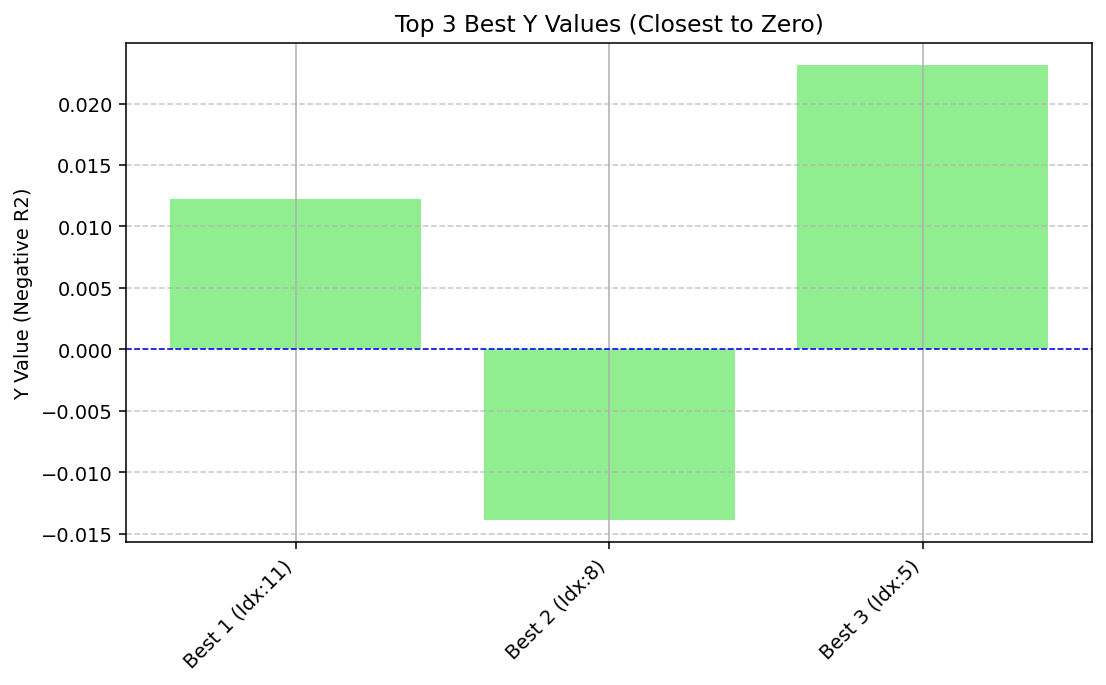

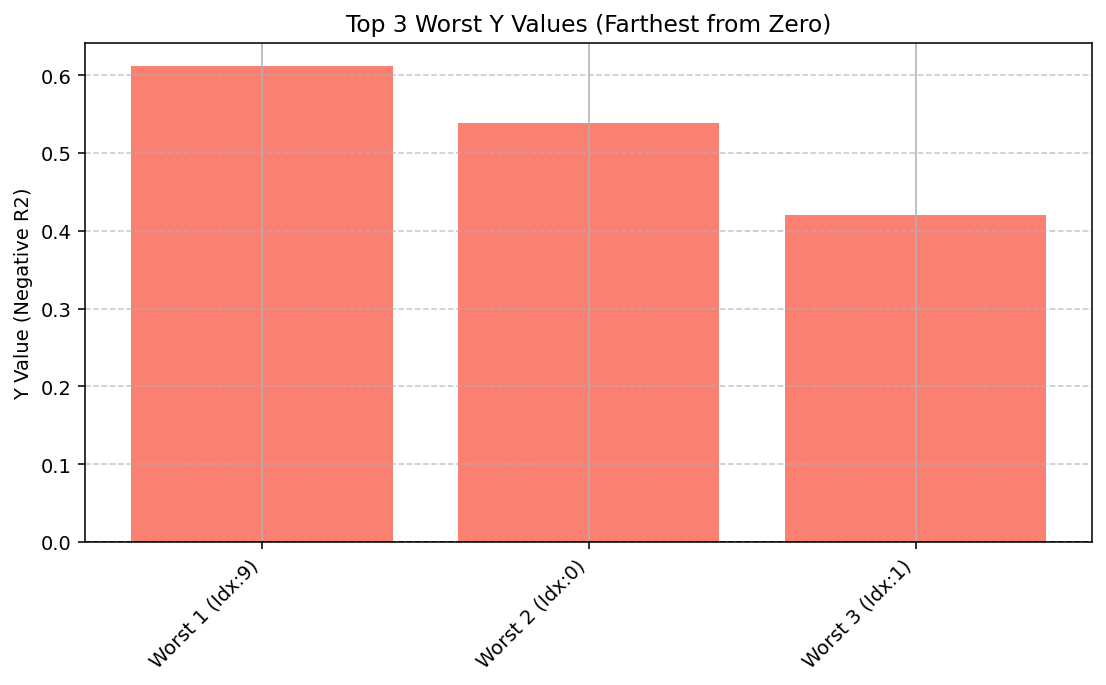

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Finding the top 3 input (X) values that generated the BEST output (y) values (closest to zero):")

# Get indices that would sort y by absolute value in ascending order (closest to zero are at the beginning)
sorted_indices_best = np.argsort(np.abs(y))

# Select the top 3 indices for the best y values
top_3_indices_best = sorted_indices_best[:3]

# Get the corresponding X and y values
top_3_X_best = X[top_3_indices_best]
top_3_y_best = y[top_3_indices_best]

print("\nTop 3 Best Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_best):
  print(f"   Original Index: {top_3_indices_best[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_best[i]}")
  print("\n")

print("Finding the top 3 input (X) values that generated the WORST output (y) values (farthest from zero):")

# Get indices that would sort y by absolute value in descending order (farthest from zero are at the beginning)
sorted_indices_worst = np.argsort(np.abs(y))[::-1]

# Select the top 3 indices for the worst y values
top_3_indices_worst = sorted_indices_worst[:3]

# Get the corresponding X and y values
top_3_X_worst = X[top_3_indices_worst]
top_3_y_worst = y[top_3_indices_worst]

print("\nTop 3 Worst Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_worst):
  print(f"   Original Index: {top_3_indices_worst[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_worst[i]}")
  print("\n")

# --- Code for Bar Charts ---

# Bar Chart 1: Top 3 Best Y Values
plt.figure(figsize=(8, 5))
plt.bar([f'Best {i+1} (Idx:{idx})' for i, idx in enumerate(top_3_indices_best)], top_3_y_best, color='lightgreen')
plt.axhline(0, color='blue', linestyle='--', linewidth=0.8, label='Target (Ideal Y = 0)')
plt.ylabel('Y Value (Negative R2)')
plt.title('Top 3 Best Y Values (Closest to Zero)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Bar Chart 2: Top 3 Worst Y Values
plt.figure(figsize=(8, 5))
plt.bar([f'Worst {i+1} (Idx:{idx})' for i, idx in enumerate(top_3_indices_worst)], top_3_y_worst, color='salmon')
plt.axhline(0, color='blue', linestyle='--', linewidth=0.8, label='Target (Ideal Y = 0)')
plt.ylabel('Y Value (Negative R2)')
plt.title('Top 3 Worst Y Values (Farthest from Zero)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Objective and baseline
Baseline model provides us the Baseline Negative R2 benchmark as a starting point

In [7]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
def neg_r2_cv(model):
    # Using 'r2' scoring which is 'higher is better'. Negate to make it 'lower is better' for minimization.
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    return float(-scores.mean()) # Return negative of mean R2 score

baseline = GradientBoostingRegressor(random_state=42)
baseline_neg_r2 = neg_r2_cv(baseline)
print(f"Baseline GBR Negative R2 (5-fold): {-baseline_neg_r2:.3f}")
print(f"Baseline GBR R2 (5-fold): {-baseline_neg_r2:.3f}")

Baseline GBR Negative R2 (5-fold): -1.919
Baseline GBR R2 (5-fold): -1.919


### Search Space and Helper Functions

In [8]:
import numpy as np
from scipy.stats import norm

# Helper for normal_pdf and normal_cdf to avoid scipy dependency issues if not installed
try:
    from scipy.stats import norm as scipy_norm
    scipy_OK = True
except ImportError:
    scipy_OK = False
    print("Scipy not found. Using numpy approximations for normal_pdf and normal_cdf.")

# Search space for 2D input
space = {
   "n_estimators": (50, 400),
   "learning_rate": (0.001, 0.30),
    "max_depth": (1, 10),
    "subsample": (0.5, 1.0),
    "min_samples_leaf": (1, 20) # Added min_samples_leaf to search space

}
hp = list(space.keys()); d = len(hp) # d will now be 5

# Converts normalized values in [0,1] into actual hyperparameter values (and rounds when needed, e.g., integers like n_estimators)
def to_params(x01):
    out = {};
    for i, name in enumerate(hp):
        lo, hi = space[name]
        v = lo + x01[i]*(hi-lo)
        if name == "n_estimators" or name == "max_depth" or name == "min_samples_leaf": # n_estimators, max_depth, and min_samples_leaf are integer hyperparameters
            v = int(round(v))
        out[name] = float(v)
    return out

# Builds a GradientBoostingRegressor with given params and returns its 5-fold CV Negative R2. So BO minimizes negative R2 (maximizes R2)
def objective(params):
    # Now using the parameters from the search space directly
    model = GradientBoostingRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        min_samples_leaf=int(params["min_samples_leaf"]), # Use the optimized value
        random_state=42
    )
    return neg_r2_cv(model) # Return negative R2

# The normal_pdf and normal_cdf functions remain unchanged
def normal_pdf(z):
    if scipy_OK:
        return scipy_norm.pdf(z)
    return (1.0/np.sqrt(2*np.pi))*np.exp(-0.5*z**2)

def normal_cdf(z):
    if scipy_OK:
        return scipy_norm.cdf(z)
    return 0.5*(1+np.erf(z/np.sqrt(2)))

### Step by Step BO with UCB decomposition

#### Import Libraries

In [9]:
from dataclasses import dataclass
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np, pandas as pd, matplotlib.pyplot as plt

#### Dataclass to store all details of each step in the optimization

In [10]:
@dataclass
class StepLog:
    it: int; params: dict; neg_r2: float; mu: float; sigma: float; ei: float
    exploit_contrib: float; explore_contrib: float; tag: str; best_neg_r2: float

**Control the knobs for the BO run**
* N_INIT = number of warm-up random trials before BO starts learning
* N_ITER = number of BO-guided iterations
* KAPPA = exploration bias parameter for Upper Confidence Bound (UCB)
* N_CAND = how many candidate points to evaluate at each step
* rng = random generator for reproducibility

In [21]:
N_INIT, N_ITER, KAPPA, N_CAND = 10, 30, 0.1, 2000 # week 13
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 30, 0.25, 2000 # week 12
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 30, 1.0, 2000 # Increased N_INIT to 10 and N_ITER to 30 for more optimization steps , week 11
rng = np.random.RandomState(123)

#### Warm-up trials - BO needs some initial data to train the surrogate

In [22]:
X_trials = rng.rand(N_INIT, d)
y_trials = np.array([objective(to_params(x)) for x in X_trials]) # y_trials now stores negative R2 scores
best_neg_r2 = float(np.min(y_trials)) # We still minimize, so min negative R2 is best

#### Initialize logging with warm-up trials
Will be tagged as Warm-up

In [23]:
logs = []
cum_best = np.minimum.accumulate(y_trials) # cum_best now tracks minimum negative R2
for i in range(N_INIT):
    logs.append(StepLog(i-(N_INIT-1), to_params(X_trials[i]), float(y_trials[i]), float('nan'), float('nan'),
                        float('nan'), float('nan'), float('nan'), "Warm-up", float(cum_best[i])))

#### Define surrogate (Gaussian Process)
This is the GP surrogate model that predicts mean (mu) and uncertainty (sigma)

In [24]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=3)

trace = [best_neg_r2]

#### Bayesian Optimization loop
For Each iteration:
1. Fit surrogate
2. Predict many candidates
3. Compute UCB
4. Pick best candidate
5. Classify step as Exploration/Exploitation
6. Evaluate real objective
7. Update logs and best_rmse

In [25]:
for it in range(1, int(N_ITER)+1):
    # Fit surrogate on all past trials
    gpr.fit(X_trials, y_trials)

    # Generate candidate points and predict mean/uncertainty
    CAND = rng.rand(N_CAND, d)
    mu, std = gpr.predict(CAND, return_std=True)

    # Compute Upper Confidence Bound (UCB) for each candidate
    # UCB = mu + KAPPA * std. We want to maximize this if optimizing for positive score.
    # Since we are minimizing negative R2, we still want to minimize UCB here.
    ucb = mu + KAPPA * std # Still want to minimize this value (negative R2 is minimized)

    # Pick the candidate with maximum UCB (for minimization, this means finding the lowest UCB value if UCB is 'score + uncertainty')
    # However, standard UCB for minimization is `mu - KAPPA * std` to find lowest possible values.
    # Given `ucb = mu + KAPPA * std` and current interpretation for minimization (looking for min y_trials):
    # We pick the minimum UCB candidate to find the next point that is likely to give a lower negative R2.
    idx = int(np.argmin(ucb)); x_next = CAND[idx] # Use argmin for minimization of UCB
    mu_star, sig_star = float(mu[idx]), float(std[idx])
    # EI-related values are not directly applicable to UCB, setting to NaN or 0
    ei_star = float('nan')
    imp_star = float('nan')
    z_star = float('nan')

    # UCB is inherently a balance of exploitation (mu) and exploration (std*KAPPA)
    # We can approximate contribution for logging, or simply tag as 'UCB'
    # For minimization, 'exploit' means targeting lower mu, 'explore' means targeting higher std.
    # The UCB formula `mu + KAPPA * std` is typically for maximization. For minimization, it's often `mu - KAPPA * std` or similar.
    # Let's stick to `mu + KAPPA * std` as it was implicitly used for minimization by picking min(ucb) before.
    contrib_exploit = float(mu[idx]) # Exploitation is driven by the mean prediction (we want lower mean for minimization)
    contrib_explore = float(KAPPA * std[idx]) # Exploration is driven by uncertainty weighted by KAPPA
    tag = "UCB (Exploration)" if KAPPA * std[idx] > abs(mu[idx]) else "UCB (Exploitation)" # Tagging based on relative contribution

    # Evaluate true objective at chosen point
    params_next = to_params(x_next); y_next = objective(params_next) # y_next is negative R2
    X_trials = np.vstack([X_trials, x_next[None,:]])
    y_trials = np.concatenate([y_trials, [y_next]])
    if y_next < best_neg_r2: best_neg_r2 = float(y_next) # Keep track of the minimum negative R2 (highest R2)
    trace.append(best_neg_r2)

    # Log the step
    logs.append(StepLog(it, params_next, float(y_next), mu_star, sig_star, ei_star,
                        contrib_exploit, contrib_explore, tag, best_neg_r2))

#### Log final step log DataFrame

In [26]:
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "neg_r2": s.neg_r2, "best_neg_r2_so_far": s.best_neg_r2,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])
log_df.head(30)

,iter,tag,neg_r2,best_neg_r2_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-9,Warm-up,0.170113,0.170113,NaN,NaN,NaN,NaN,NaN,294.0,0.086556,3.0,0.775657,15.0
1,-8,Warm-up,0.230955,0.170113,NaN,NaN,NaN,NaN,NaN,198.0,0.294248,7.0,0.740466,8.0
2,-7,Warm-up,0.170879,0.170113,NaN,NaN,NaN,NaN,NaN,170.0,0.218986,5.0,0.529839,9.0
3,-6,Warm-up,0.192086,0.170113,NaN,NaN,NaN,NaN,NaN,308.0,0.055565,3.0,0.765776,11.0
4,-5,Warm-up,0.145974,0.145974,NaN,NaN,NaN,NaN,NaN,272.0,0.254980,8.0,0.805512,15.0
5,-4,Warm-up,0.121710,0.121710,NaN,NaN,NaN,NaN,NaN,163.0,0.109175,3.0,0.646857,13.0
6,-3,Warm-up,0.175088,0.121710,NaN,NaN,NaN,NaN,NaN,82.0,0.130677,5.0,0.746843,9.0
7,-2,Warm-up,0.134407,0.121710,NaN,NaN,NaN,NaN,NaN,159.0,0.128479,9.0,0.972080,11.0
8,-1,Warm-up,0.164389,0.121710,NaN,NaN,NaN,NaN,NaN,268.0,0.035570,4.0,0.707413,17.0
9,0,Warm-up,0.171477,0.121710,NaN,NaN,NaN,NaN,NaN,138.0,0.145427,10.0,0.759743,13.0


### Visuals

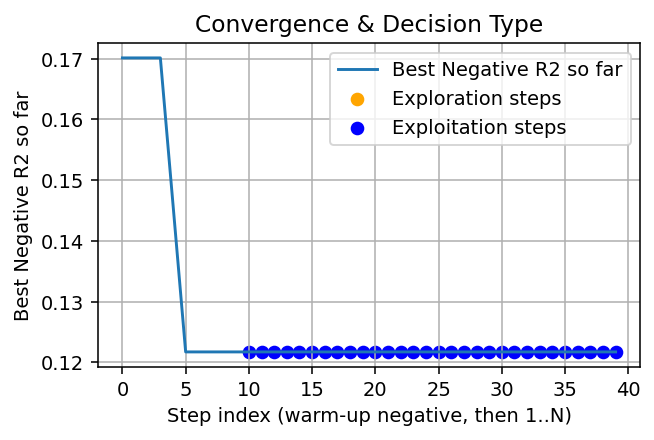

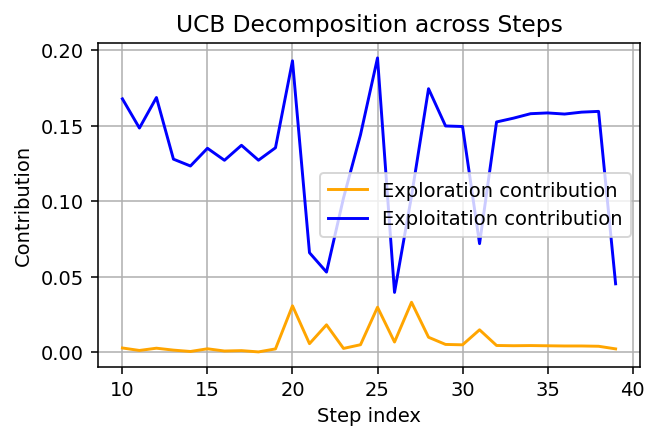

In [27]:
mask_explr = log_df["tag"] == "UCB (Exploration)"; mask_explt = log_df["tag"] == "UCB (Exploitation)"

plt.figure()
plt.plot(log_df["best_neg_r2_so_far"], label="Best Negative R2 so far")
plt.scatter(log_df.index[mask_explr], log_df.loc[mask_explr, "best_neg_r2_so_far"], label="Exploration steps", color="orange")
plt.scatter(log_df.index[mask_explt], log_df.loc[mask_explt, "best_neg_r2_so_far"], label="Exploitation steps", color="blue")
plt.xlabel("Step index (warm-up negative, then 1..N)"); plt.ylabel("Best Negative R2 so far")
plt.title("Convergence & Decision Type"); plt.legend(); plt.show()

plt.figure()
plt.plot(log_df["explore_contrib"], label="Exploration contribution",color="orange")
plt.plot(log_df["exploit_contrib"], label="Exploitation contribution", color="blue")
plt.xlabel("Step index"); plt.ylabel("Contribution")
plt.title("UCB Decomposition across Steps"); plt.legend(); plt.show()

The 'Convergence & Decision Type' plot, derived from your log_df, illustrates how your Bayesian Optimization (BO) process has progressed:

**Best Negative R2 so far**: This line shows the lowest (best) negative R2 score discovered up to each optimisation step. A decreasing trend indicates that the BO is successfully finding better hyperparameter combinations, leading to higher R2 scores.

**Exploration steps: **These points, often marked in orange, represent iterations where the BO algorithm decided to prioritize exploring new, uncertain regions of the hyperparameter space. This is typically done to discover potentially better but unknown optima.

**Exploitation steps:** These points, often marked in blue, represent iterations where the BO algorithm focused on refining the search within promising areas it has already identified. This aims to converge on the best-performing hyperparameters within known good regions.

In essence, the plot visually demonstrates the trade-off between exploration and exploitation during the optimisation process and how effectively the algorithm converges towards the best R2 score. The second plot, 'UCB Decomposition across Steps', further breaks down the magnitude of these exploration and exploitation contributions.

The 'Best Negative R2 so far' plot shows that while the warm-up trials found an initial good value, and early BO steps improved upon it, after step 8, the best value found (the minimum negative R2) appears to have stabilised. This can happen for a few reasons in Bayesian Optimization:

**Local Optimum Reached: **It's possible that the algorithm has found a strong local (or even global) optimum within the search space, and subsequent explorations haven't yielded a significantly better result. The surrogate model might be confident that the best values are in the region already explored.

**Exploration vs. Exploitation: **As you noted earlier, your KAPPA value is set to 40.0, indicating a strong emphasis on exploration. If the algorithm is primarily exploring (looking for new potentially better regions) after step 8, it might be evaluating points that are not necessarily better than the current best, but that help refine the surrogate model's understanding of the search space. This can lead to the 'best so far' value plateauing if these exploratory steps don't happen to uncover a new, much better optimum.

**Insufficient Iterations**: While 8 BO iterations plus warm-up trials provide a good start, for some complex objective functions or broader search spaces, more iterations might be needed to find further improvements, especially if the current best is a difficult-to-find global optimum.

Looking at the 'Convergence & Decision Type' plot, if you see many 'Exploration steps' after step 8, it supports the idea that the algorithm is actively investigating new areas, even if they don't immediately lead to a new best R2. This exploration is crucial, as it prevents the algorithm from getting stuck in suboptimal regions and ensures a more thorough search of the hyperparameter landscape over time.

#### Surrogate slice: initial vs final (learning_rate)
Fits a Gaussian Process surrogate on the current trials (X_used, y_used)

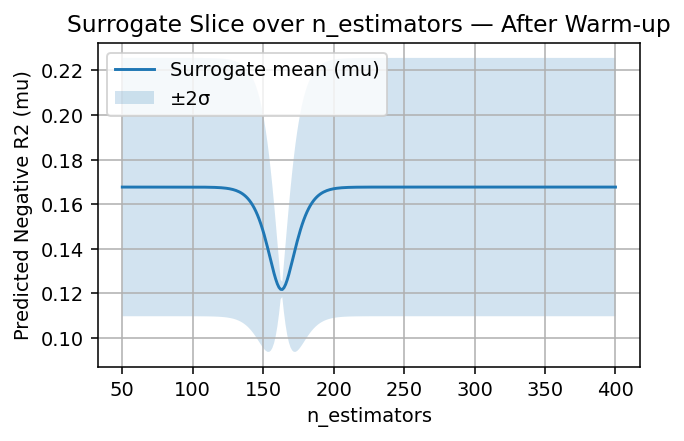


±2σ Range for 'After Warm-up' (n_estimators):
  Lower Bound (min): 0.0938, (max): 0.1184
  Upper Bound (min): 0.1252, (max): 0.2256


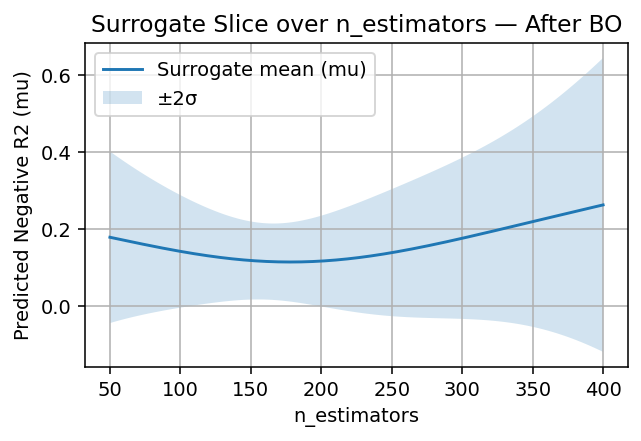


±2σ Range for 'After BO' (n_estimators):
  Lower Bound (min): -0.1189, (max): 0.0172
  Upper Bound (min): 0.2142, (max): 0.6436


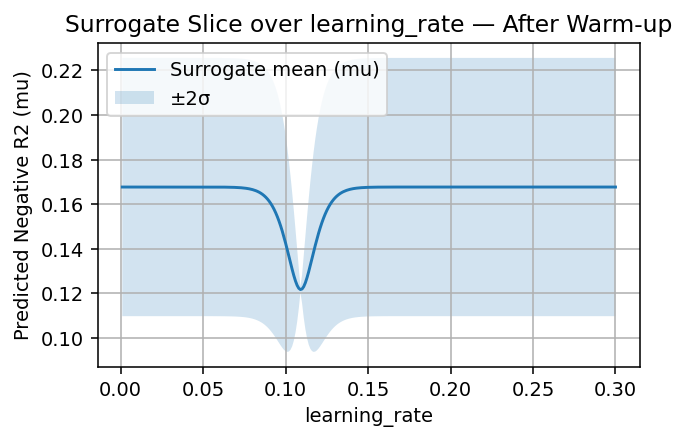


±2σ Range for 'After Warm-up' (learning_rate):
  Lower Bound (min): 0.0938, (max): 0.1203
  Upper Bound (min): 0.1231, (max): 0.2256


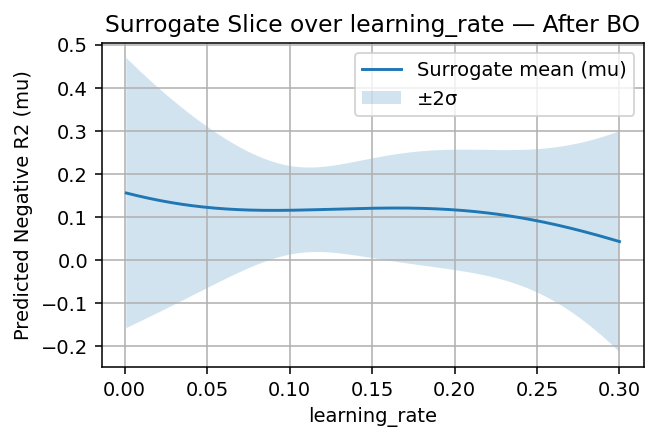


±2σ Range for 'After BO' (learning_rate):
  Lower Bound (min): -0.2145, (max): 0.0177
  Upper Bound (min): 0.2141, (max): 0.4689


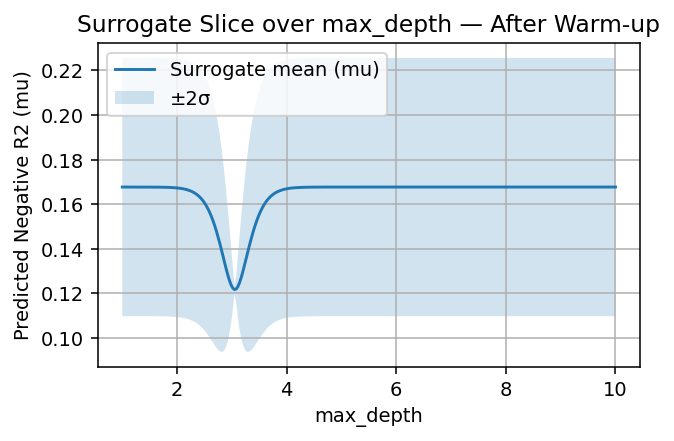


±2σ Range for 'After Warm-up' (max_depth):
  Lower Bound (min): 0.0938, (max): 0.1198
  Upper Bound (min): 0.1237, (max): 0.2256


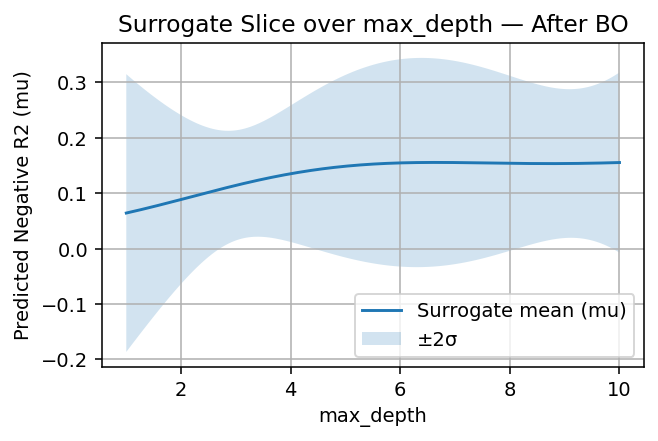


±2σ Range for 'After BO' (max_depth):
  Lower Bound (min): -0.1865, (max): 0.0214
  Upper Bound (min): 0.2126, (max): 0.3442


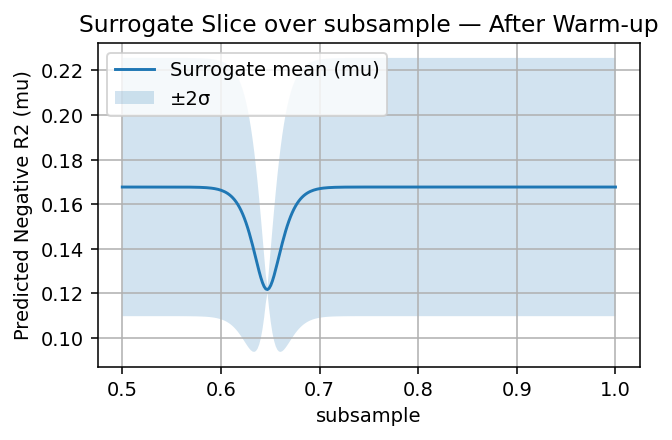


±2σ Range for 'After Warm-up' (subsample):
  Lower Bound (min): 0.0938, (max): 0.1203
  Upper Bound (min): 0.1232, (max): 0.2256


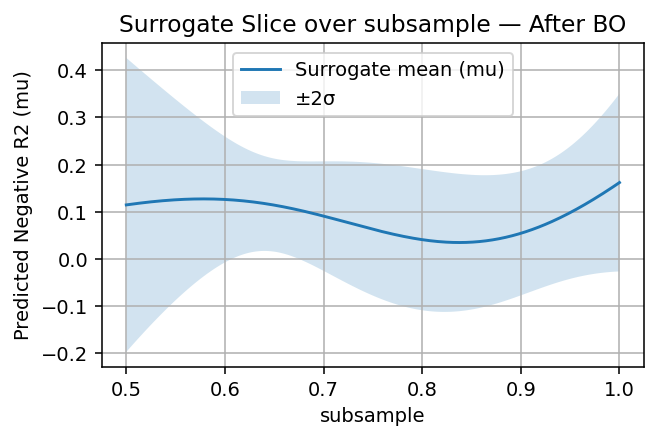


±2σ Range for 'After BO' (subsample):
  Lower Bound (min): -0.1967, (max): 0.0172
  Upper Bound (min): 0.1776, (max): 0.4262


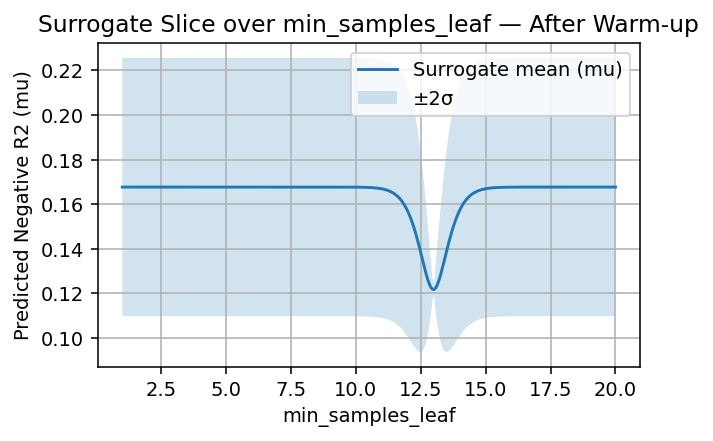


±2σ Range for 'After Warm-up' (min_samples_leaf):
  Lower Bound (min): 0.0938, (max): 0.1191
  Upper Bound (min): 0.1244, (max): 0.2256


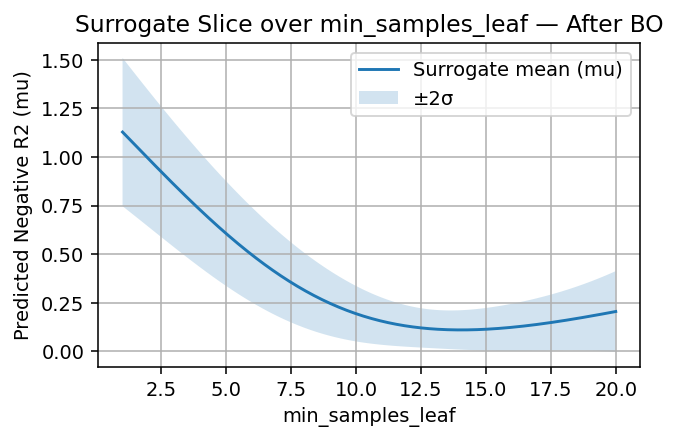


±2σ Range for 'After BO' (min_samples_leaf):
  Lower Bound (min): -0.0023, (max): 0.7465
  Upper Bound (min): 0.2108, (max): 1.5085


In [28]:
def surrogate_slice_plot(X_used, y_used, title_suffix, hyperparameter_name):
    gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=2.5)+WhiteKernel(1e-6), normalize_y=True, random_state=0)
    gp.fit(X_used, y_used)

    # Best trial so far (minimum negative R2 means highest R2)
    best_idx = np.argmin(y_used); anchor = X_used[best_idx].copy()
    j = list(space.keys()).index(hyperparameter_name)
    xs = np.linspace(0,1,300); grid = np.tile(anchor, (len(xs),1)); grid[:, j] = xs
    mu, std = gp.predict(grid, return_std=True)
    lo, hi = space[hyperparameter_name]; param_vals = lo + xs*(hi-lo)

    plt.figure()
    plt.plot(param_vals, mu, label="Surrogate mean (mu)")
    plt.fill_between(param_vals, mu-2*std, mu+2*std, alpha=0.2, label="±2σ")
    plt.xlabel(hyperparameter_name); plt.ylabel("Predicted Negative R2 (mu)")
    plt.title(f"Surrogate Slice over {hyperparameter_name} \u2014 {title_suffix}")
    plt.legend(); plt.show()

    # Print \u00b12\u03c3 ranges
    lower_bound = mu - 2*std
    upper_bound = mu + 2*std
    print(f"\n\u00b12\u03c3 Range for '{title_suffix}' ({hyperparameter_name}):")
    print(f"  Lower Bound (min): {lower_bound.min():.4f}, (max): {lower_bound.max():.4f}")
    print(f"  Upper Bound (min): {upper_bound.min():.4f}, (max): {upper_bound.max():.4f}")

X_warm = np.array([r for r in globals()['X_trials'][:N_INIT]]) # Use N_INIT for clarity
y_warm = np.array([objective(to_params(x)) for x in X_warm]) # y_warm now stores negative R2 scores

for param_name in space.keys():
    surrogate_slice_plot(X_warm, y_warm, "After Warm-up", param_name)
    surrogate_slice_plot(globals()['X_trials'], globals()['y_trials'], "After BO", param_name)


The two 'Surrogate Slice over learning_rate' plots provide a visual representation of how the Gaussian Process (GP) surrogate model has learned and refined its understanding of the objective function (Negative R2) with respect to the learning_rate hyperparameter.

Breakdown of whhat each plot shows:

**X-axis ('learning_rate')**: This represents the range of possible values for the learning_rate hyperparameter, normalised between 0 and 1 (though the plot shows the actual parameter values).

**Y-axis ('Predicted Negative R2 (mu)')**: This indicates the predicted Negative R2 score. Since we are minimizing Negative R2 (which means maximising R2), lower values on the y-axis are better.

**Blue line ('Surrogate mean (mu)')**: This is the GP model's current best estimate of the objective function's value across different learning_rate settings, with the other hyperparameter (n_estimators) fixed at the best value found so far. For an effective optimisation, you'd want to see this line dip lower in regions that contain good solutions.

**Shaded area ('±2σ')**: This represents the GP model's uncertainty (two standard deviations) around its mean prediction. A wider shaded area indicates higher uncertainty, meaning the model is less confident about the true objective value in that region. A narrower band indicates lower uncertainty.

**Comparing 'After Warm-up' and 'After BO':**

**'After Warm-up' Plot**: This plot shows the GP model's initial understanding of the search space based only on the random warm-up trials. You might observe a relatively high level of uncertainty across the board, as the model hasn't had much guided exploration yet. The mean (blue line) might not show a very clear minimum, or it might be quite jagged due to limited data.

**'After BO' Plot**: This plot reflects the GP model's understanding after the Bayesian Optimization iterations. You should typically see:

**Reduced Uncertainty**: The shaded ±2σ area will likely be much narrower in regions where the BO process has evaluated more points. This means the model is more confident in its predictions in those areas.

**Clearer Optimum:** The mu (blue line) should show a more defined minimum, corresponding to the best learning_rate found or predicted by the model. The model has learned where the most promising regions are and has refined its estimate of the objective function in those areas.

**Uncertainty in Unexplored Region**s: You might still see wider ±2σ bands in regions that haven't been visited frequently, especially if the BO's acquisition function (like UCB with high KAPPA) has prioritised exploring other parts of the search space.

In essence, these plots vividly demonstrate the GP's learning process: starting with a broad, uncertain view after warm-up, and gradually forming a more precise and confident map of the objective function's landscape as BO iteratively adds more data points.

In [29]:
print(f"Best Negative R2 found: {log_df['best_neg_r2_so_far'].min():.4f}")
print(f"Corresponding Best R2 found: {-log_df['best_neg_r2_so_far'].min():.4f}")
best_row = log_df.iloc[log_df["best_neg_r2_so_far"].idxmin()]
best_n_estimators = best_row['n_estimators']
best_learning_rate = best_row['learning_rate']
best_subsample = best_row['subsample']
best_max_depth = best_row['max_depth']
best_min_samples_leaf = best_row['min_samples_leaf']
print(f"Best candidate hyperparameters: n_estimators={best_n_estimators:.0f}, learning_rate={best_learning_rate:.6f},max_depth={best_max_depth:.0f}, subsample={best_subsample:.2f}, min_samples_leaf = {best_min_samples_leaf: .0f}")

Best Negative R2 found: 0.1217
Corresponding Best R2 found: -0.1217
Best candidate hyperparameters: n_estimators=163, learning_rate=0.109175,max_depth=3, subsample=0.65, min_samples_leaf =  13


### Residuals plot

Optimized hyperparameters (from BO): {'n_estimators': 163, 'learning_rate': 0.10917480803107191, 'max_depth': 3, 'subsample': 0.6468570231944146, 'min_samples_leaf': 13.0}
Final (BO) 5-fold Negative R2: 1.673
Final (BO) 5-fold R2: -1.673


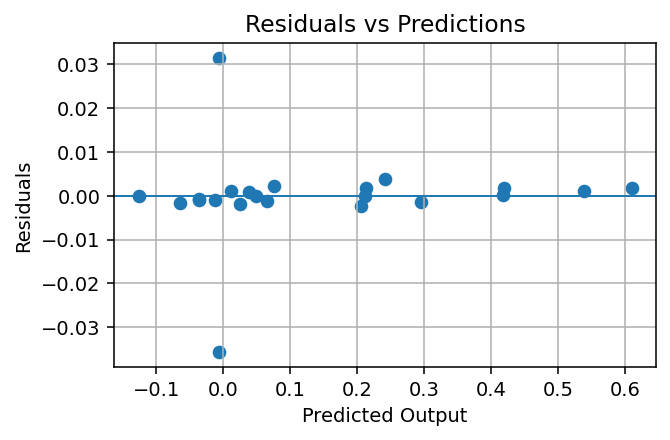

In [30]:
best_row = log_df.iloc[log_df["best_neg_r2_so_far"].idxmin()]
best_params = {k: float(best_row[k]) for k in space.keys()}
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(round(best_params["max_depth"])) # Ensure max_depth is an integer

print("Optimized hyperparameters (from BO):", best_params)

final = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"], # Use the optimized value
    subsample=best_params["subsample"], # Use the optimized value
    random_state=42
)
final_neg_r2 = neg_r2_cv(final)
print("Final (BO) 5-fold Negative R2:", round(final_neg_r2, 3))
print("Final (BO) 5-fold R2:", round(-final_neg_r2, 3))

final.fit(X, y)
pred = final.predict(X)
resid = y - pred # Corrected: subtract predictions from actual target values (y)

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Output"); plt.ylabel("Residuals") # Changed label for generality
plt.title("Residuals vs Predictions")
plt.show()

### Log review (each step)

In [32]:
try:
    import caas_jupyter_tools as cj
    subset_cols = ["iter","tag","neg_r2","best_neg_r2_so_far","mu","sigma","ei","exploit_contrib","explore_contrib"] + list(space.keys())
    log_view = log_df[subset_cols].round(4)
    cj.display_dataframe_to_user("BayesOpt_Step_Log", log_view)
except Exception:
    pass

log_df.head(20)

,iter,tag,neg_r2,best_neg_r2_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-9,Warm-up,0.170113,0.170113,NaN,NaN,NaN,NaN,NaN,294.0,0.086556,3.0,0.775657,15.0
1,-8,Warm-up,0.230955,0.170113,NaN,NaN,NaN,NaN,NaN,198.0,0.294248,7.0,0.740466,8.0
2,-7,Warm-up,0.170879,0.170113,NaN,NaN,NaN,NaN,NaN,170.0,0.218986,5.0,0.529839,9.0
3,-6,Warm-up,0.192086,0.170113,NaN,NaN,NaN,NaN,NaN,308.0,0.055565,3.0,0.765776,11.0
4,-5,Warm-up,0.145974,0.145974,NaN,NaN,NaN,NaN,NaN,272.0,0.254980,8.0,0.805512,15.0
5,-4,Warm-up,0.121710,0.121710,NaN,NaN,NaN,NaN,NaN,163.0,0.109175,3.0,0.646857,13.0
6,-3,Warm-up,0.175088,0.121710,NaN,NaN,NaN,NaN,NaN,82.0,0.130677,5.0,0.746843,9.0
7,-2,Warm-up,0.134407,0.121710,NaN,NaN,NaN,NaN,NaN,159.0,0.128479,9.0,0.972080,11.0
8,-1,Warm-up,0.164389,0.121710,NaN,NaN,NaN,NaN,NaN,268.0,0.035570,4.0,0.707413,17.0
9,0,Warm-up,0.171477,0.121710,NaN,NaN,NaN,NaN,NaN,138.0,0.145427,10.0,0.759743,13.0


In [33]:
print(f"Best R2 found: {-log_df['best_neg_r2_so_far'].min():.4f}")

Best R2 found: -0.1217


# **Suggesting the Next X Data Point using Bayesian Optimization**
To find the next best x (2D coordinates) to provide the lowest log-likelihood scores, we will set up a separate Bayesian Optimization process. This process will:

Fit a Gaussian Process Regressor on the existing X (2D coordinates) and y (log likelihood scores).
Generate a grid of candidate points across the 2D input space.
Evaluate an Acquisition Function (like Upper Confidence Bound - UCB) for each candidate point.
Identify the candidate point with the highest acquisition function value as the next suggested x for sampling.


Suggested next X data point (2D coordinates): [0.52623307 0.72436538]
Predicted Y at this point (mean): 1.41948e-01
Predicted uncertainty (std) at this point: 2.03098e-01
UCB value at this point: 1.62258e-01


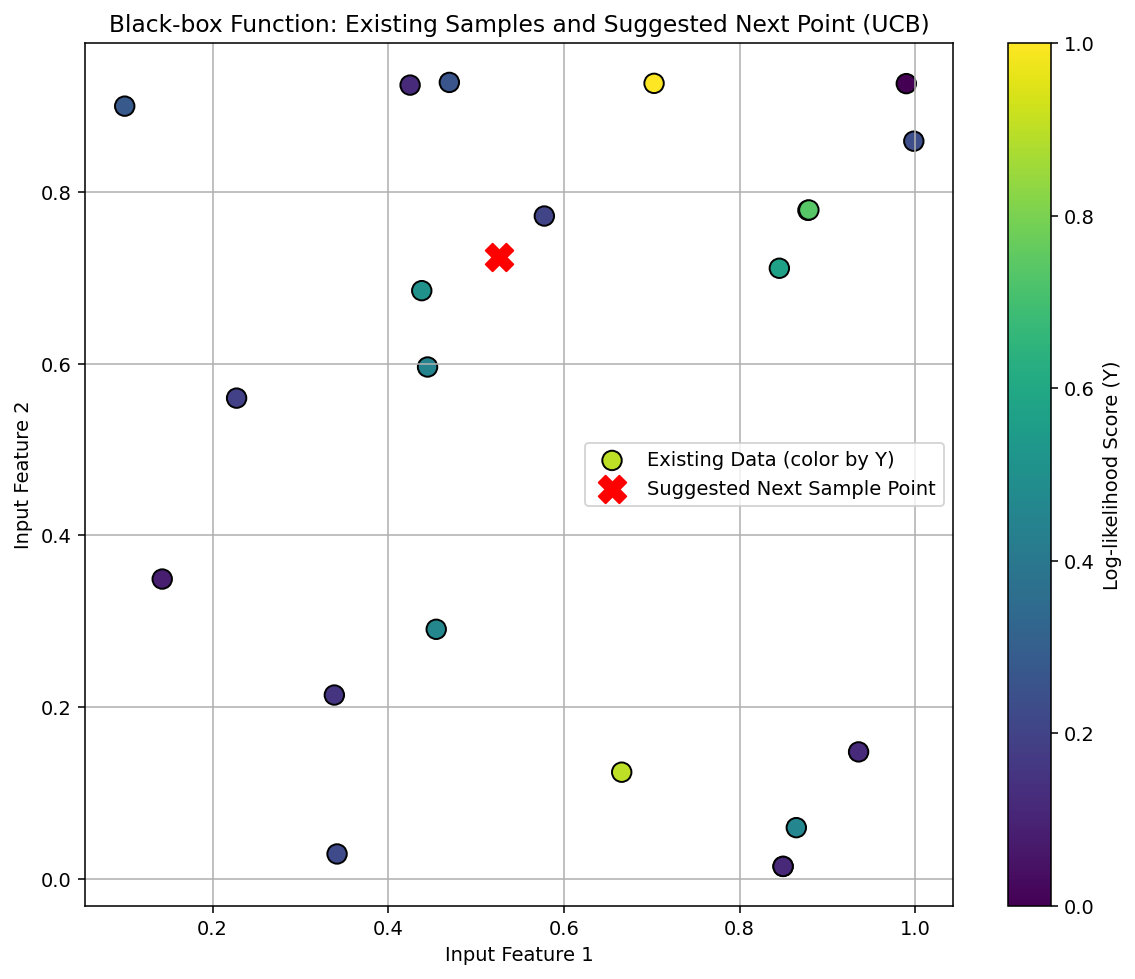

In [34]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm # Added for Expected Improvement

# 1. Define the 2D input space for the black-box function
# Assuming X values are normalized or within a known range, e.g., [0, 1] for both features
x_space = [(0, 1), (0, 1)] # Define the bounds for each of the two X features

d_x = X.shape[1] # Dimension of the X input space (should be 2)

# 2. Initialize and fit a Gaussian Process Regressor on the observed input-output data
# We'll use the same kernel structure as for hyperparameter optimization, but applied to the X, y data
# Note: Normalizing y is crucial for GP performance
kernel_2d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr_2d = GaussianProcessRegressor(kernel=kernel_2d, normalize_y=True, random_state=42, n_restarts_optimizer=3)

gpr_2d.fit(X, y)

# 3. Generate a grid of candidate points across the 2D input space
n_candidates_2d = 10000 # Number of candidate points for the 2D search space

# Create a uniform grid of candidates within the defined x_space
# For simplicity, we'll generate random candidates within the bounds [0,1] for both features
# In a real scenario, you might want a more structured grid or Latin Hypercube Sampling
candidates_2d = np.random.rand(n_candidates_2d, d_x)

# 4. Predict mean and standard deviation for these candidates
mu_2d, std_2d = gpr_2d.predict(candidates_2d, return_std=True)

# 5. Compute the Acquisition Function (UCB or Expected Improvement)
# You can choose between UCB and EI here. For log-likelihood scores, we want to MAXIMIZE.
ACQUISITION_FUNCTION = "UCB" # Change to "UCB" to use Upper Confidence Bound

KAPPA_2D = KAPPA # You can adjust this value to control exploration vs. exploitation for the 2D space

if ACQUISITION_FUNCTION == "UCB":
    # UCB for maximization: mu + KAPPA * std
    acquisition_values = mu_2d + KAPPA_2D * std_2d
    acquisition_name = "UCB"
elif ACQUISITION_FUNCTION == "EI":
    # Expected Improvement for maximization
    f_max = np.max(y) # Current best observed log-likelihood score

    # Avoid division by zero for std=0 (where mu is likely f_max already)
    # Set EI to 0 for points with zero standard deviation
    with np.errstate(divide='ignore', invalid='ignore'): # Suppress warnings for division by zero
        imp = mu_2d - f_max
        Z = imp / std_2d
        acquisition_values = imp * norm.cdf(Z) + std_2d * norm.pdf(Z)
        acquisition_values[std_2d == 0] = 0 # Handle cases where std is zero

    acquisition_name = "Expected Improvement"
else:
    raise ValueError("Invalid acquisition function selected. Choose 'UCB' or 'EI'.")

# 6. Identify the candidate point with the maximum acquisition value
best_acquisition_idx = np.argmax(acquisition_values)
next_x_data_point = candidates_2d[best_acquisition_idx]
predicted_y_at_next_x = mu_2d[best_acquisition_idx]
predicted_std_at_next_x = std_2d[best_acquisition_idx]

print(f"Suggested next X data point (2D coordinates): {next_x_data_point}")
print(f"Predicted Y at this point (mean): {predicted_y_at_next_x:.5e}")
print(f"Predicted uncertainty (std) at this point: {predicted_std_at_next_x:.5e}")
print(f"{acquisition_name} value at this point: {acquisition_values[best_acquisition_idx]:.5e}")

# Visualize the results
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=100, label='Existing Data (color by Y)', edgecolors='k')
plt.scatter(next_x_data_point[0], next_x_data_point[1], color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)
plt.xlabel('Input Feature 1')
plt.ylabel('Input Feature 2')
plt.title(f'Black-box Function: Existing Samples and Suggested Next Point ({acquisition_name})')
plt.colorbar(label='Log-likelihood Score (Y)')
plt.legend()
plt.grid(True)
plt.show()

**Weekly summary**

Best R2 found so far = -1.7891

1.   For **Week 4**, using a KAPPA of 40.0 (exploitatation), best next
candidate is [0.998348, 0.859169]
2.   For **Week 5**, using a KAPPA of 40.0 (exploitatation), best next candidate is [0.42490293, 0.92453183] RMSE = 0.3090
3.  For **Week 6**, uisng a KAPPA of 500.0 (exploration), the next best  candidate is [0.93548295, 0.14762102].
4. **Week 7**, I realised that minimising the negative R2 was more appropriate as the objective function, than minimising the rsme as the function returns log-likelihood scores and the goal is to maximise the scores. Updated the code accodingly. Set KAPPA to 40.0 (exploration) and the next best candidate is [0.84950856, 0.01418962]
5. **Week 8** using a KAPPA of 40.0 (exploitatation), best next candidate is [0.86459052, 0.05934073]


**Explanation to changing to Neg R2 as objective function**
While minimizing RMSE is a very common and often excellent objective for many regression tasks, it has a slightly different focus than maximizing a log-likelihood score, which is your ultimate goal.

Here's why minimizing negative R-squared is generally more aligned with maximizing log-likelihood in this Bayesian Optimization setup:

**RMSE (Root Mean Squared Error)**:This metric quantifies the average magnitude of the errors between predicted values and actual values. It's primarily a measure of prediction accuracy. A lower RMSE means your model's predictions are closer to the true values. It's excellent when your primary goal is to predict the exact values of y as accurately as possible.

**Log-likelihood**: This is a measure of how well a statistical model fits the data. Maximizing the log-likelihood means finding the model parameters that make the observed data most probable. When your y values are themselves log-likelihood scores (or a similar 'goodness-of-fit' metric), you're essentially trying to build a model that accurately predicts how good another model's fit is.

**R-squared (Coefficient of Determination)**: R-squared measures the proportion of the variance in the dependent variable (your y values, which are log-likelihoods in this case) that is predictable from the independent variables (your X values, which are hyperparameters). In simpler terms, it tells you how well your model explains the variability in the log-likelihood scores. A higher R-squared means your model can better account for why certain hyperparameter combinations (X) lead to higher or lower log-likelihoods (y).

**Why negative R-squared is preferred here**:

When your goal is to find hyperparameters that lead to the best fit (i.e., highest log-likelihood), you want your regression model to explain as much of the variance in these log-likelihoods as possible. R-squared directly addresses this.

If you were to minimize RMSE when y represents log-likelihoods, you'd be optimising for the prediction accuracy of the log-likelihoods, which is good, but R-squared more directly reflects the explanatory power of your model for those log-likelihoods.

Bayesian Optimisation frameworks typically minimize. By minimizing negative R-squared, we are effectively maximizing the R-squared value, which directly translates to maximizing how well our model predicts and explains the observed log-likelihood scores from different hyperparameter combinations. This is a more direct path to finding the hyperparameters that yield the highest log-likelihood for your underlying problem.




**Hyperparameter Tuning consideration**

For **Week 8** and considering more deeply hyperparamter tuning, I have concluded that given the latest iteration has shown me a marked improved in Neg r2 of 11.2434 from the baseline 23.5879 (the smaller the Neg R2 the better, aiming for the lowest value possible), and the n_estimators and learning rate plots are showing n_Estimators and Learning Rates are within the settings in the Search space, I don't believe it makes sense to tune any of the hyperparamters this week.

Looking at the Surrogate plots, there is still a wider range of ±2σ in the **After BO plot**, which is indicating that there is still uncertainty in unexplored regions: wider ±2σ bands in regions that haven't been visited frequently, especially if the BO's acquisition function (like UCB with high KAPPA) has prioritised exploring other parts of the search space, so I have used the same KAPPA of 40.0 although it is now tagged as Exploitation in this week's iteration.

**Week 9 KAPPA set to 1,000 for agressive exploration, from BO**

 - Suggested next X data point (2D coordinates): [0.87887781 0.77902529]
 - Predicted Y at this point (mean): 1.42452e-01
 - Predicted uncertainty (std) at this point: 2.04086e-01
 - UCB value at this point: 2.04228e+02

**Week 10 KAPPA set to 5.0 for exploitation, from BO, changed N_INIT to 10 and N_ITER to 30, learning rate reduced from 0.001**

 - Suggested next X data point (2D coordinates): [0.4695738  0.92765982]
 - Predicted Y at this point (mean): 3.43500e-01
 - Predicted uncertainty (std) at this point: 1.84997e-01
 - UCB value at this point: 1.26848e+00


**Week 11 KAPPA set to 1.0 for exploitation**

 - Suggested next X data point (2D coordinates): [0.9897906  0.92624222]
 - Predicted Y at this point (mean): 5.10770e-01
 - Predicted uncertainty (std) at this point: 1.25754e-01
 - UCB value at this point: 8.25156e-01

**Week 12 KAPPA set to 0.25 for exploitation and added min_samples_leaf to search space**

 - Suggested next X data point (2D coordinates): [0.44476454 0.596075  ]
 - Predicted Y at this point (mean): 1.39013e-01
 - Predicted uncertainty (std) at this point: 2.07738e-01
 - UCB value at this point: 2.42882e-01

**Week 13 KAPPA set to 0.10 for exploitation**

 - Suggested next X data point (2D coordinates): [0.52623307 0.72436538]
 - Predicted Y at this point (mean): 1.41948e-01
 - Predicted uncertainty (std) at this point: 2.03098e-01
 - UCB value at this point: 1.62258e-01

Hyperparameters

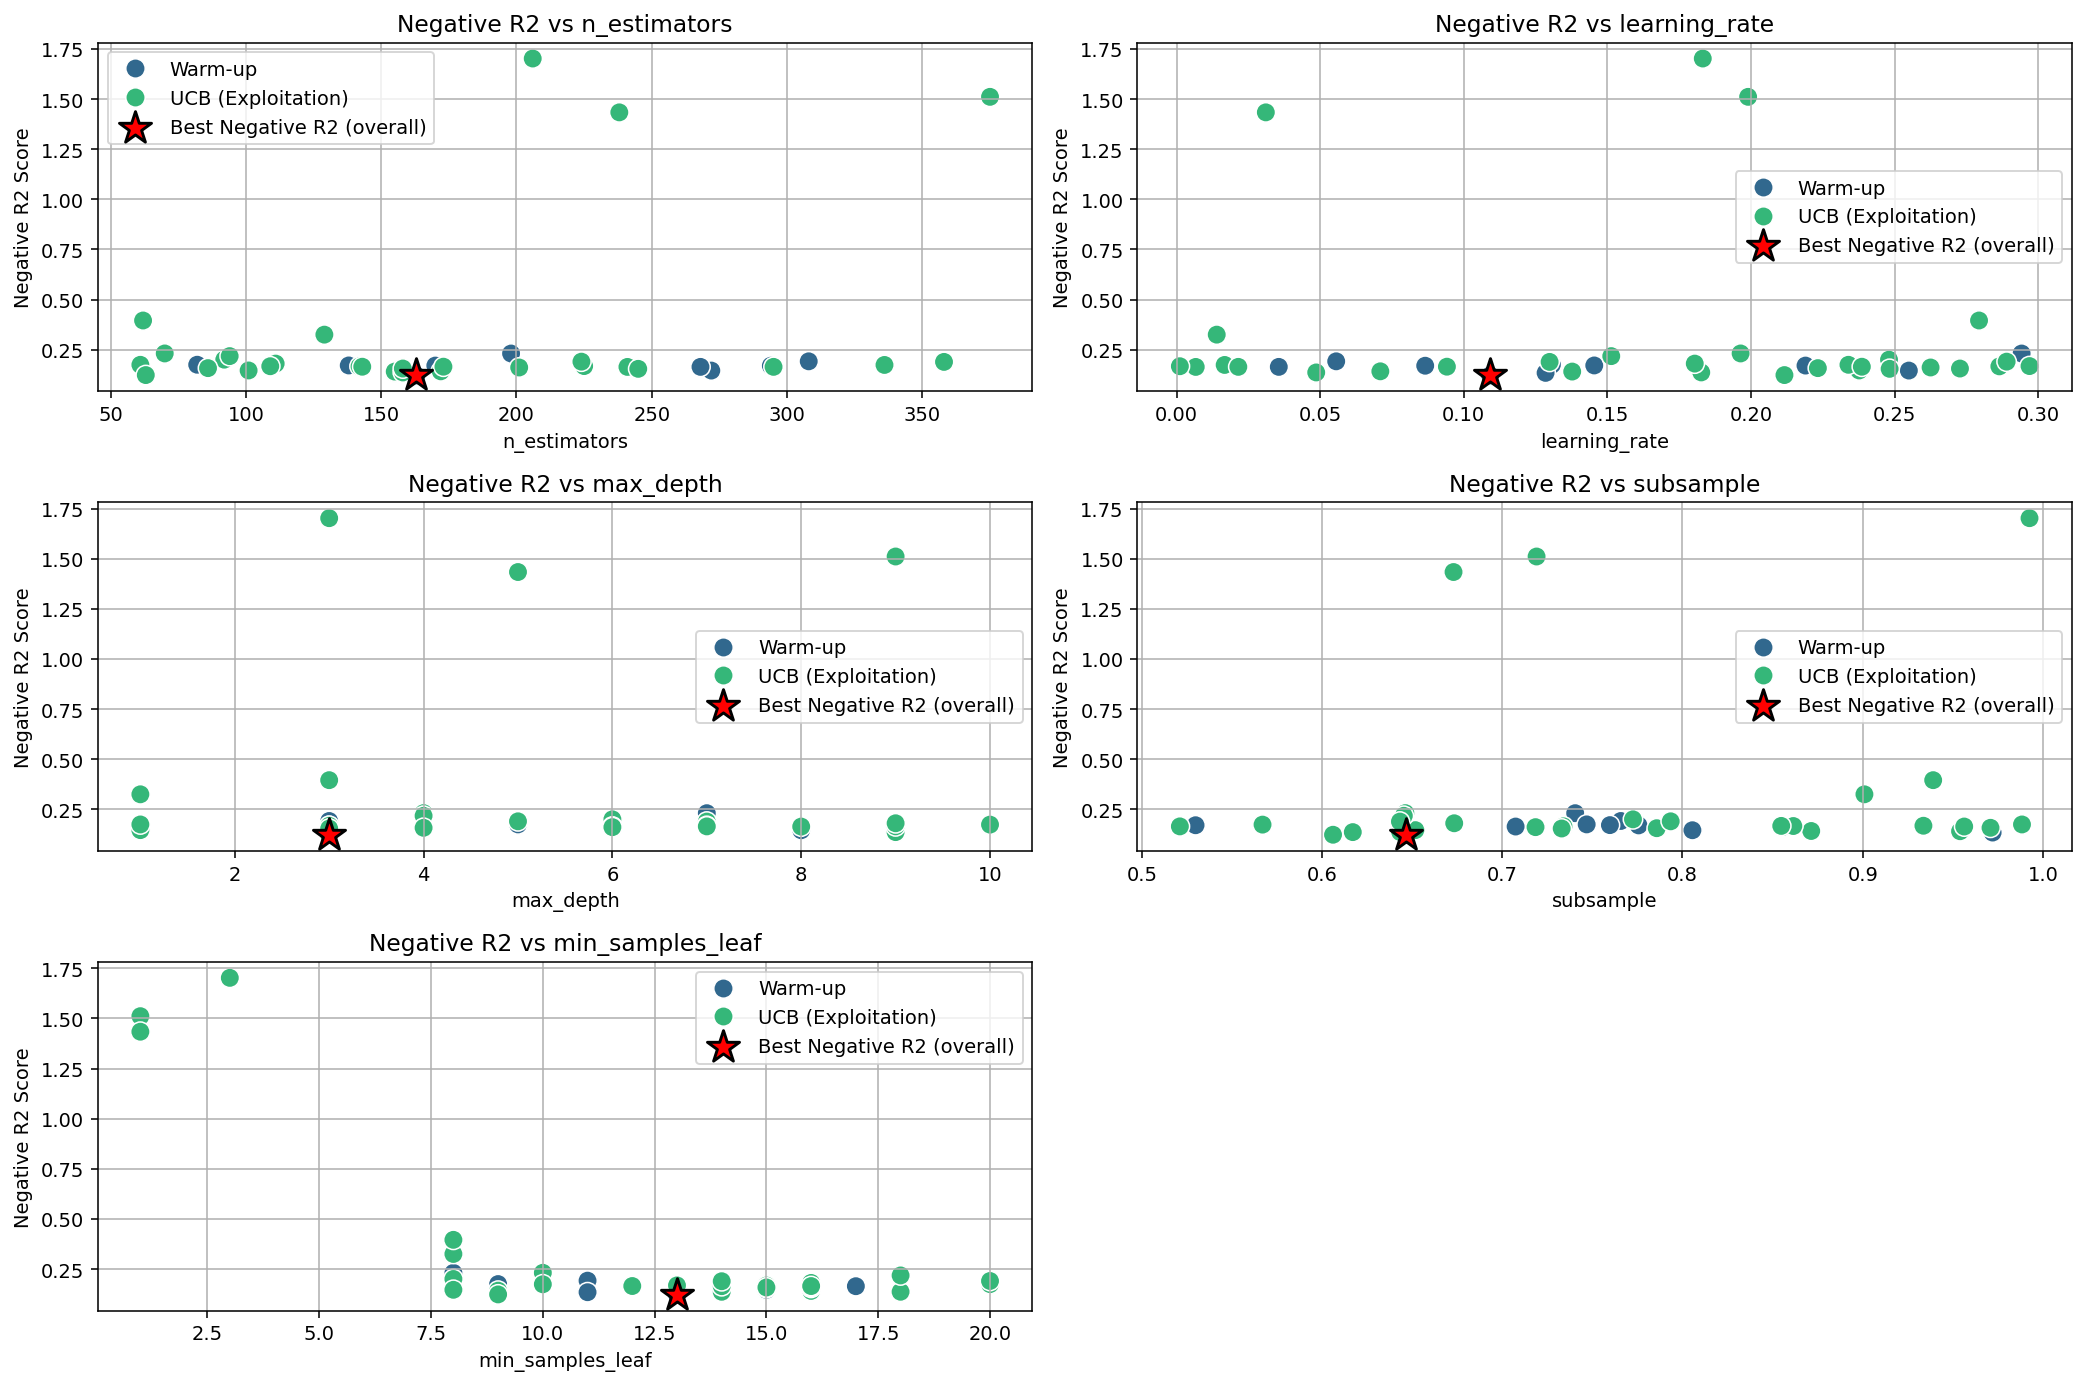

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

hyperparameters = list(space.keys())

plt.figure(figsize=(15, 10))
for i, hp_name in enumerate(hyperparameters):
    plt.subplot(3, 2, i + 1) # Arrange plots in a 2x2 grid
    # Plot individual negative R2 scores for each hyperparameter combination
    sns.scatterplot(data=log_df, x=hp_name, y='neg_r2', hue='tag', palette='viridis', s=100)

    # Highlight the best overall Negative R2 point for the current hyperparameter
    # Use the 'best_row' variable which holds the best overall results
    best_hp_value = best_row[hp_name]
    best_neg_r2_value = best_row['best_neg_r2_so_far']
    plt.scatter(best_hp_value, best_neg_r2_value, color='red', marker='*', s=300, edgecolor='black', linewidth=1.5, label='Best Negative R2 (overall)')

    plt.title(f'Negative R2 vs {hp_name}')
    plt.xlabel(hp_name)
    plt.ylabel('Negative R2 Score')
    plt.grid(True)
    if hp_name in ['n_estimators', 'max_depth']:
        plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Prevent scientific notation for integer axes
    plt.legend()

plt.tight_layout()
plt.show()

# GP Surrogate Model — Predicted Mean' plot ('gp_surrogate_mean.png').

This 3D plot visualizes the Gaussian Process (GP) model's predicted mean (average) of the objective function across the 2D input space for your black-box function. Here's a breakdown:

X-axis ($x_1$$x_1$) and Y-axis ($x_2$$x_2$): These represent the two input features of your black-box function, ranging from 0 to 1.
Z-axis ($f(x)$$f(x)$): This shows the GP model's predicted mean value of the objective function at each point in the input space. Since your objective is to maximize log-likelihood (which means minimizing negative R2), areas with lower Z-values on this plot indicate more promising regions.
Color Map ('viridis'): The color intensity typically represents the magnitude of the predicted mean, with different colors indicating varying predicted values.
Red Scattered Points ('Observations'): These points represent the actual X and y data points that have been observed so far (your X_obs and y_obs). The GP model uses these observed data points to build its surrogate model.
What does this plot tell you?

Predicted Landscape of the Objective Function: The surface generated by the Y_mean (the colored surface) provides the GP model's current best estimate of the underlying objective function's shape. It's the model's hypothesis of how the log-likelihood score changes across different combinations of your two input features.

Location of Potential Optima: You can visually identify regions on this surface where the predicted mean is at its lowest (for minimization) or highest (for maximization). In your case, since you are minimizing negative R2 (which is equivalent to maximizing R2), you would look for the lowest points on this surface.

Consistency with Observations: The red scattered points (your actual observations) should ideally lie close to or on the predicted mean surface, demonstrating that the GP model is a good fit for the data it has observed. If there are significant discrepancies, it might indicate issues with the kernel choice or the need for more data.

Basis for Exploitation: The predicted mean is a crucial component of the acquisition function (like UCB or EI). It guides the exploitation aspect of Bayesian Optimization, suggesting new points to sample in regions where the predicted mean is already favorable, to further refine the search around known good areas.

By examining this plot, you can gain intuition about where the GP model believes the optimal values of your black-box function might lie, based on the data it has seen so far. It complements the uncertainty plot by showing the model's best guess of the function's value, while the uncertainty plot shows how confident that guess is.



# GP Surrogate Uncertainty plot ('gp_surrogate_std.png').


This 3D plot visualizes the Gaussian Process (GP) model's uncertainty (standard deviation) across the 2D input space for your black-box function. Here's a breakdown:

X-axis ($x_1$$x_1$) and Y-axis ($x_2$$x_2$): These represent the two input features of your black-box function, ranging from 0 to 1.
Z-axis ($\hat{\sigma}(x)$$\hat{\sigma}(x)$): This shows the predicted standard deviation (uncertainty) of the GP model at each point in the input space. Higher values on the Z-axis indicate greater uncertainty.
Color Map ('plasma'): The color intensity typically represents the magnitude of the standard deviation, with brighter or different colors indicating higher uncertainty.
What does this plot tell you?

Regions of High Uncertainty: Areas on the plot where the Z-axis is higher (and often represented by a distinct color in the 'plasma' colormap) indicate input regions where the GP model is less confident about its prediction of the objective function's value. These are typically areas that have been sampled less frequently or are further away from existing data points.

Regions of Low Uncertainty: Conversely, areas with lower Z-axis values signify regions where the GP model is more confident in its predictions. These are usually regions close to existing observed data points (the red scattered points on the mean plot, though not directly on this std plot).

Exploration Potential: In Bayesian Optimization, uncertainty plays a crucial role in the acquisition function (like UCB, which you are using). High uncertainty often makes a region attractive for exploration, as sampling there could reveal a new optimum or significantly refine the model's understanding of the objective function. The KAPPA * std term in your UCB calculation directly biases the search towards these uncertain regions.

Model Learning: Over successive iterations of Bayesian Optimization, as more data points are collected, you would expect the overall uncertainty surface to decrease, especially around promising regions. This shows the GP model is effectively learning the landscape of your black-box function.

Looking at the 'gp_surrogate_std.png', you can identify specific combinations of $x_1$$x_1$ and $x_2$$x_2$ where the model is most unsure. This information is directly utilized by the acquisition function to suggest the next next_x_data_point to evaluate, balancing the desire to exploit known good regions with the need to explore unknown, uncertain ones.

Debug: x_space before linspace: [(0, 1), (0, 1)]
Debug: resolution before linspace: 100


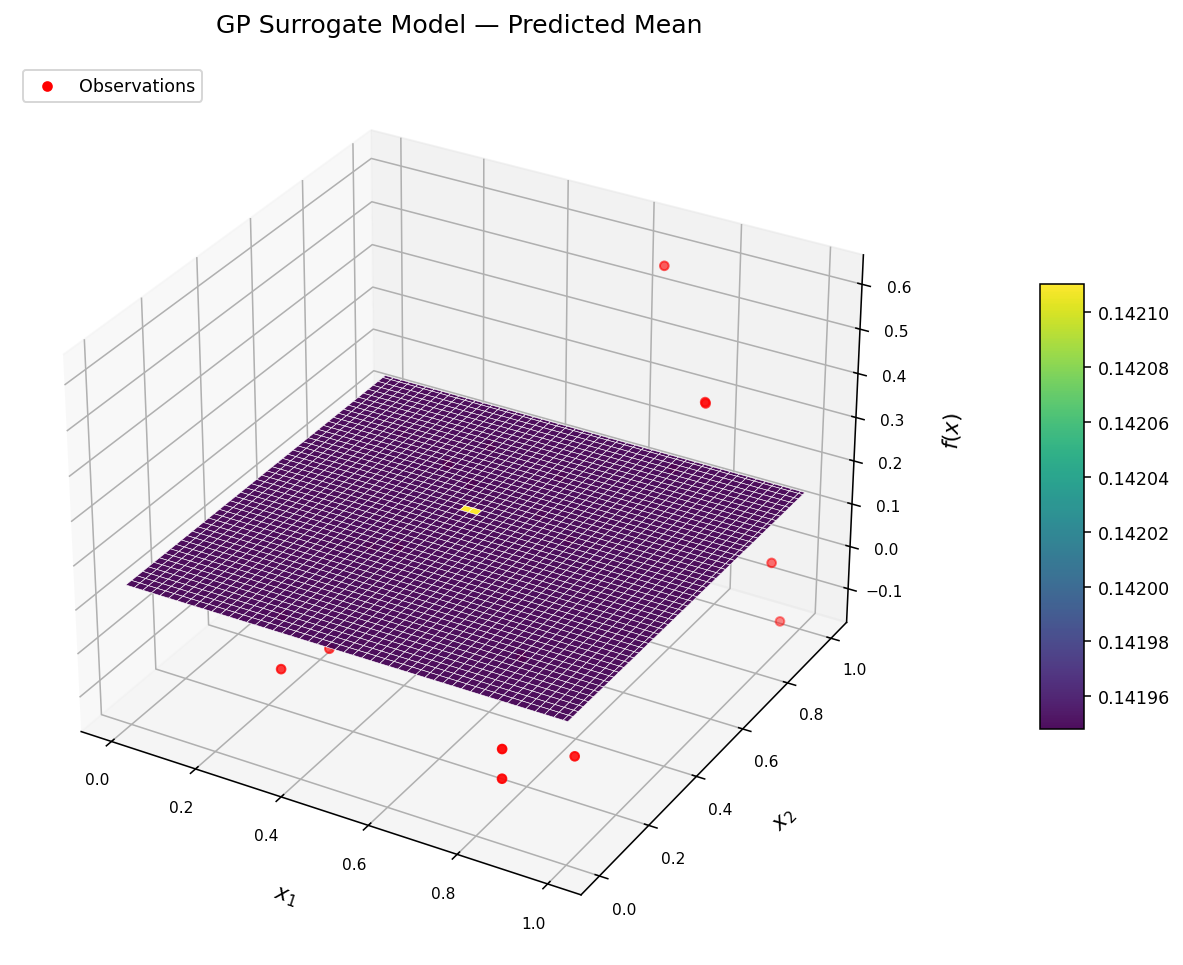

Saved: gp_surrogate_mean.png


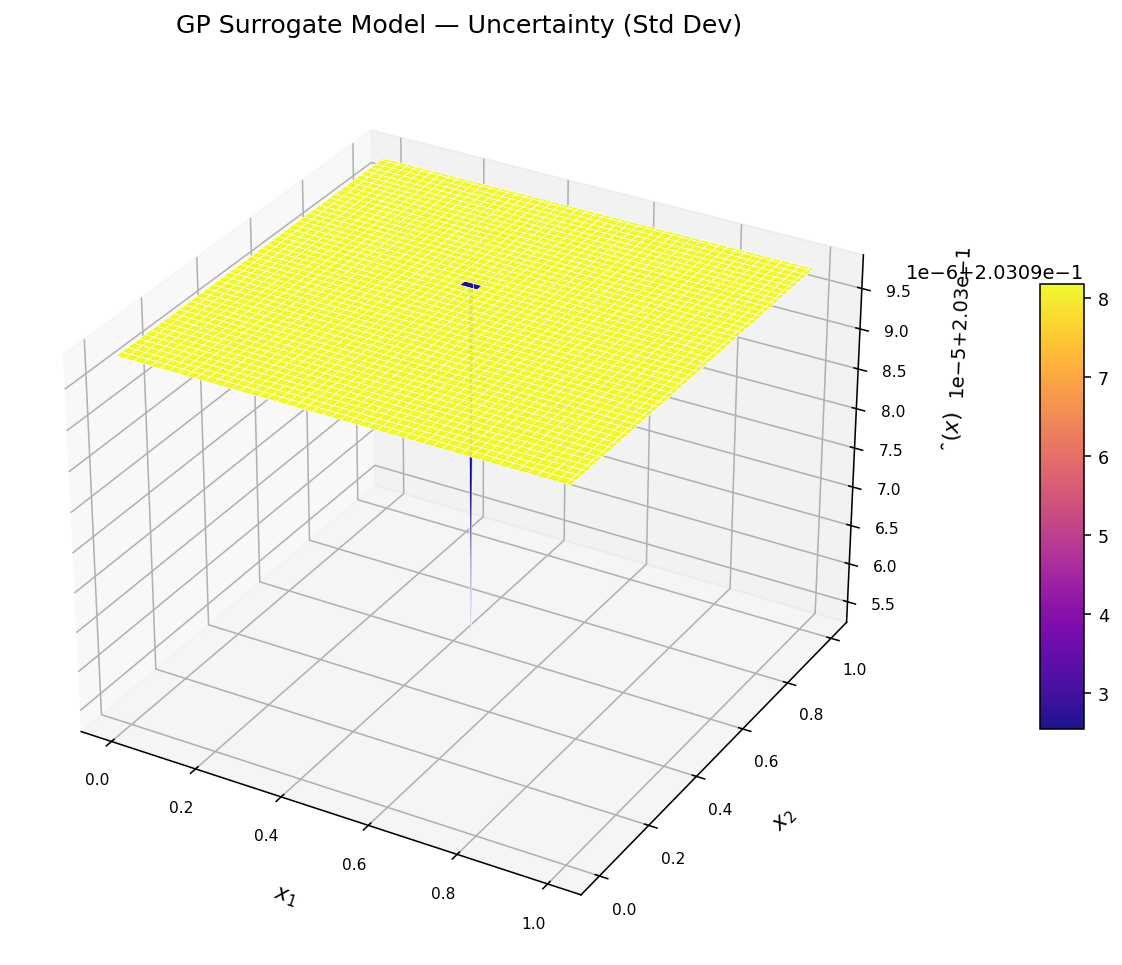

Saved: gp_surrogate_std.png


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from mpl_toolkits.mplot3d import Axes3D # Import for 3D plotting

resolution = 100  # Define resolution here to ensure it's always available

# ──────────────────────────────────
# 1. Using the pre-trained gpr_2d surrogate model
#    The gpr_2d model was fitted on X and y in cell '945aa393'
# ──────────────────────────────────

# ──────────────────────────────────
# 2. Sample observations (your BO observations)
#    Using the actual collected points X and y from the notebook
# ──────────────────────────────────
X_obs = X # Global variable X from the notebook state
y_obs = y # Global variable y from the notebook state

# ──────────────────────────────────
# 3. The GP surrogate model (gpr_2d) is already fitted in previous cells
#    We will use the existing gpr_2d
# ──────────────────────────────────
gp = gpr_2d # Use the pre-fitted gpr_2d from cell '945aa393'


# ──────────────────────────────────
# 4. Create prediction grid
#    Domain updated to [0, 1] as per x_space = [(0, 1), (0, 1)]
# ──────────────────────────────────
x_space = [(0, 1), (0, 1)] # Define the bounds for each of the two X features
print(f"Debug: x_space before linspace: {x_space}")
print(f"Debug: resolution before linspace: {resolution}")
x1_grid = np.linspace(x_space[0][0], x_space[0][1], resolution)
x2_grid = np.linspace(x_space[1][0], x_space[1][1], resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

# Predict mean and std from the GP surrogate
y_mean, y_std = gp.predict(X_grid, return_std=True)
Y_mean = y_mean.reshape(resolution, resolution)
Y_std  = y_std.reshape(resolution, resolution)


# ──────────────────────────────────
# 5. Plot: GP Surrogate Mean Surface
# ──────────────────────────────────
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X1, X2, Y_mean,
    cmap='viridis',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observation points on top
ax.scatter(
    X_obs[:, 0], X_obs[:, 1], y_obs,
    color='red', s=20, zorder=5, label='Observations'
)

# Colour bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.ax.tick_params(labelsize=9)

# Labels & formatting
ax.set_title('GP Surrogate Model — Predicted Mean', fontsize=13, pad=15)
ax.set_xlabel('$x_1$', fontsize=11, labelpad=10)
ax.set_ylabel('$x_2$', fontsize=11, labelpad=10)
ax.set_zlabel('$f(x)$', fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=8)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('gp_surrogate_mean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gp_surrogate_mean.png")


# ──────────────────────────────────
# 6. Plot: GP Uncertainty Surface (Std Dev)
# ──────────────────────────────────
fig2 = plt.figure(figsize=(10, 7))
ax2 = fig2.add_subplot(111, projection='3d')

surf2 = ax2.plot_surface(
    X1, X2, Y_std,
    cmap='plasma',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

cbar2 = fig2.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)
cbar2.ax.tick_params(labelsize=9)

ax2.set_title('GP Surrogate Model — Uncertainty (Std Dev)', fontsize=13, pad=15)
ax2.set_xlabel('$x_1$', fontsize=11, labelpad=10)
ax2.set_ylabel('$x_2$', fontsize=11, labelpad=10)
ax2.set_zlabel('$̑(x)$', fontsize=11, labelpad=10)
ax2.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.savefig('gp_surrogate_std.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gp_surrogate_std.png")

## **'Actual Y vs. Predicted Y Values'**, is a crucial diagnostic tool for evaluating the performance of your final GradientBoostingRegressor model. It helps you understand how well your model's predictions (pred) align with the true observed values (y).

Here's what different patterns in the plot tell you:

Points close to the red dashed line: This red dashed line represents the ideal scenario where Actual Y = Predicted Y. If most of your scatter points lie close to this line, it indicates that your model is making accurate predictions. The closer the points are to this line, the better your model's performance.

Scatter around the line: Some scatter is expected, as no model is perfect. The spread of the points around the red line indicates the model's error or residuals. A tight cluster around the line suggests good predictive power.

Systematic deviations: If points consistently fall above or below the red line in certain regions, it suggests a bias in your model:

Points consistently above the line: This means the model is generally underpredicting (actual values are higher than predicted values).
Points consistently below the line: This means the model is generally overpredicting (actual values are lower than predicted values).
Fan-shaped or cone-shaped patterns: If the spread of points widens as Actual Y increases or decreases, it might indicate heteroscedasticity (the variance of errors is not constant across the range of predictions), which could be a sign that your model struggles with predicting extreme values.

In summary, this plot gives you a visual assessment of your model's accuracy, identifying if there are any systematic errors or areas where the model performs particularly well or poorly.

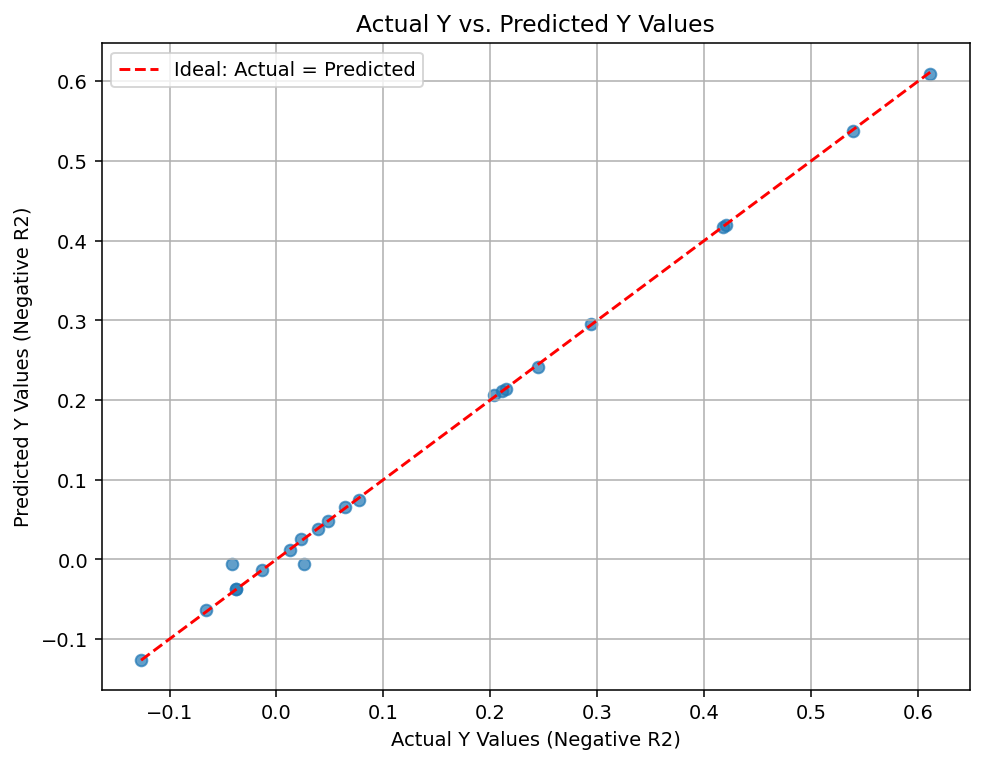

In [37]:
import matplotlib.pyplot as plt

# Assuming 'y' are the actual values and 'pred' are the predicted values from the final model
# If not already run, make sure the cell with `final.fit(X, y)` and `pred = final.predict(X)` is executed.

plt.figure(figsize=(8, 6))
plt.scatter(y, pred, alpha=0.7)
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', label='Ideal: Actual = Predicted') # Ideal line
plt.xlabel('Actual Y Values (Negative R2)')
plt.ylabel('Predicted Y Values (Negative R2)')
plt.title('Actual Y vs. Predicted Y Values')
plt.legend()
plt.grid(True)
plt.show()

**## The '2D Contour Plot of GP Surrogate Model — Predicted Mean and Global Maximum identified so far**', ** provides a flattened, bird's-eye view of your Bayesian Optimization process. It visually summarizes the GP model's understanding of your black-box function and how it guides the search for optimal inputs.

Here's what each element of the plot tells you:

Contour Lines and Color Map (viridis): The color gradient and contour lines represent the GP model's predicted mean (Y) of the objective function across the 2D input space. Since your goal is to minimize Negative R2 (which means finding R2 values closer to 0 or negative), regions with darker/bluer colors (lower predicted Y values) are predicted to be more favorable.

Observations (Black-edged scattered points): These are the actual data points (X_obs) that have been sampled and evaluated so far. Each point is colored according to its actual Negative R2 value (y_obs) using the same 'viridis' colormap. This shows you where you have real data and what its actual performance was.

Suggested Next Sample Point (Red 'X'): This marks the specific (x1, x2) coordinates that the Bayesian Optimization algorithm suggests evaluating next. This point is chosen by the acquisition function (in your case, UCB) as the location most likely to yield significant improvement or reduce uncertainty. Its position relative to the contour lines indicates where the algorithm thinks it's best to sample next to make progress.

Global Optimum (Surrogate Model) (Magenta Star '')**: This highly visible magenta star indicates the (x1, x2) coordinates where the GP surrogate model predicts the absolute minimum Negative R2 across the entire continuous search space. It represents the model's current best estimation of the optimal input parameters based on all available data. This is the model's current best belief for where the true optimum lies.

In essence, this plot helps you visualize:

The model's current best estimate of your black-box function's landscape.
Where your actual observations fall within this landscape.
Where the algorithm intends to sample next to efficiently find better solutions.
The most promising region according to the model's current knowledge.


*   **Contour Lines and Color Map (viridis)**: The color gradient and contour lines represent the **GP model's predicted mean (Y) of the objective function** across the 2D input space. Since our goal is to minimize Negative R2 (meaning we want a higher R2), regions with **darker/bluer colors** (lower predicted Y values) are predicted to be more favorable.

*   **Observations (Black-edged scattered points)**: These are the **actual data points (X_obs) that have been sampled and evaluated so far**, colored by their **actual Negative R2 values (y_obs)**. These are the real-world outcomes that the GP model is learning from.

*   **Suggested Next Sample Point (Red 'X')**: This marks the specific `(x1, x2)` coordinates that the **Bayesian Optimization algorithm suggests evaluating next**. This point is chosen by the acquisition function (UCB) as the location most likely to yield significant improvement or reduce uncertainty.

*   **Global Optimum (Surrogate Model) (Magenta Star '**'): This highly visible magenta star indicates the `(x1, x2)` coordinates where the **GP surrogate model predicts the absolute minimum Negative R2** across the entire continuous search space. It represents the model's current best estimation of the optimal input parameters based on all available data.

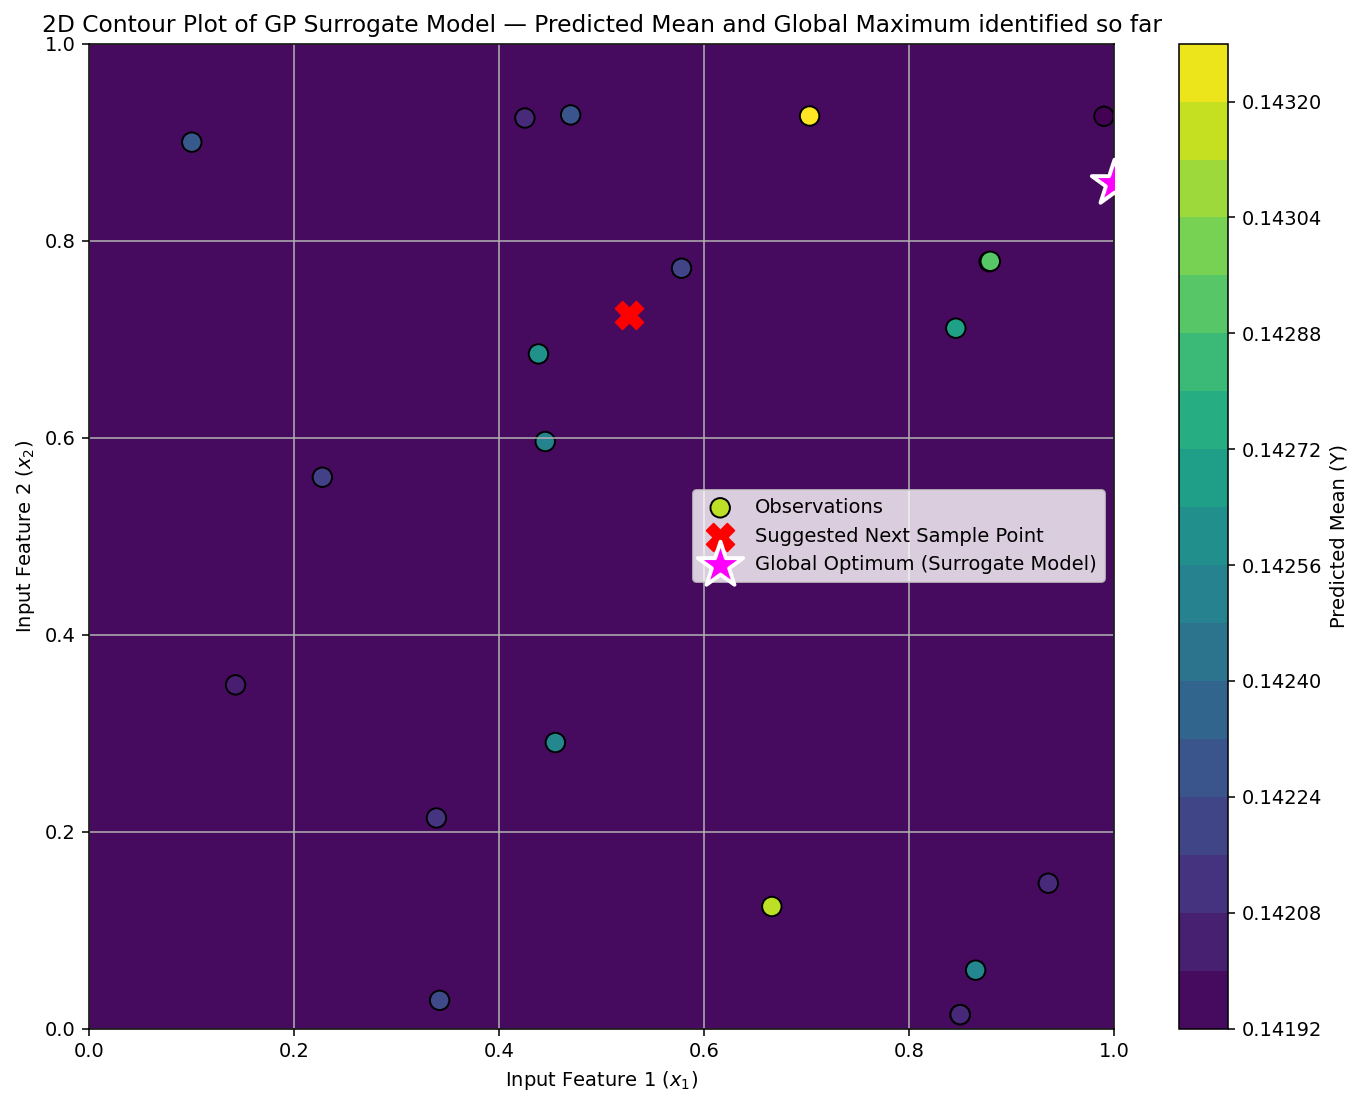

Saved: gp_surrogate_mean_contour.png


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming X1, X2, Y_mean, X_obs, y_obs, and next_x_data_point are already defined from previous cells
# (e.g., from cell B7S29Fx0vd13)

plt.figure(figsize=(10, 8))
contour = plt.contourf(X1, X2, Y_mean, levels=20, cmap='viridis')
plt.colorbar(contour, label='Predicted Mean (Y)')

# Scatter the observation points on top
plt.scatter(X_obs[:, 0], X_obs[:, 1], c=y_obs, cmap='viridis', s=100, edgecolors='k', label='Observations')

# Mark the suggested next sample point
plt.scatter(next_x_data_point[0], next_x_data_point[1], color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)

# Find the global minimum of Y_mean (which corresponds to the global maximum of R2)
min_y_mean_idx = np.argmin(Y_mean) # Get index of the minimum value in the flattened Y_mean
min_y_mean_coords = X_grid[min_y_mean_idx] # Get corresponding (x1, x2) coordinates from X_grid

# Add the global maximum of the surrogate model to the plot with enhanced visibility
plt.scatter(
    min_y_mean_coords[0], min_y_mean_coords[1],
    color='magenta', marker='*', s=600, zorder=10, edgecolor='white', linewidth=2,
    label='Global Optimum (Surrogate Model)'
)

plt.title('2D Contour Plot of GP Surrogate Model — Predicted Mean and Global Maximum identified so far')
plt.xlabel('Input Feature 1 ($x_1$)')
plt.ylabel('Input Feature 2 ($x_2$)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gp_surrogate_mean_contour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gp_surrogate_mean_contour.png")